# Energy-aware Slice Placement – Data Analysis

This notebook analyzes the results obtained from the execution of the proposed
energy-aware MILP and heuristic algorithms for 5G slice placement.

The analysis focuses on:
- acceptance rate 
- total energy consumption,
- node activation and CPU utilization,
- routing characteristics,
- scalability and runtime behavior.

All results are generated from CSV files produced by the simulation pipeline.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (7,4)
plt.rcParams["font.size"] = 11
sns.set_style("whitegrid")


In [15]:
RESULTS_DIR = "./results/2026-02-27_17-14-35"  # ajuste aqui

df_metrics = pd.read_csv(f"{RESULTS_DIR}/scalability_results.csv")
df_routes = pd.read_csv(f"{RESULTS_DIR}/routes_all_methods.csv")
df_node_cpu = pd.read_csv(f"{RESULTS_DIR}/node_cpu_load_all_methods.csv")
df_node_vnfs = pd.read_csv(f"{RESULTS_DIR}/node_vnfs_all_methods.csv")


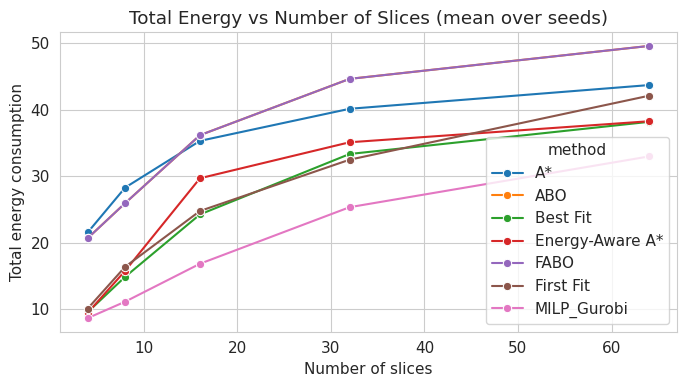

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Normalize column names
df = df_metrics.copy()
df.columns = [c.strip().lower() for c in df.columns]

# Map common alternatives to "method" if needed
if "method" not in df.columns:
    for alt in ["methods", "algorithm", "algo", "name", "model", "solver", "approach"]:
        if alt in df.columns:
            df = df.rename(columns={alt: "method"})
            break

# If method is still missing, it might be the index
if "method" not in df.columns and df.index.name in ("method", "methods", "algorithm"):
    df = df.reset_index()

# Final guardrail
required = {"method", "num_slices", "total_energy"}
missing = required - set(df.columns)
if missing:
    raise KeyError(f"Missing columns in df_metrics: {missing}. Available: {list(df.columns)}")

energy_avg = (
    df.groupby(["method", "num_slices"], as_index=False)["total_energy"]
      .mean()
)

sns.lineplot(
    data=energy_avg,
    x="num_slices",
    y="total_energy",
    hue="method",
    marker="o"
)

plt.xlabel("Number of slices")
plt.ylabel("Total energy consumption")
plt.title("Total Energy vs Number of Slices (mean over seeds)")
plt.tight_layout()
plt.show()


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Load ---
df = pd.read_csv(f"{RESULTS_DIR}/scalability_results.csv")

# --- Normalize column names (handles Method vs method, spaces, etc.) ---
df.columns = [c.strip().lower() for c in df.columns]

# --- Map common alternative names to expected ones (if any) ---
rename_map = {}
if "method" not in df.columns:
    for alt in ["methods", "algorithm", "algo", "approach", "solver"]:
        if alt in df.columns:
            rename_map[alt] = "method"
            break

if "num_slices" not in df.columns:
    for alt in ["slices", "n_slices", "num_slice", "requested_slices", "requested"]:
        if alt in df.columns:
            rename_map[alt] = "num_slices"
            break

if "num_vnfs_per_slice" not in df.columns:
    for alt in ["vnfs_per_slice", "num_vnfs", "vnf_per_slice", "k", "chain_len"]:
        if alt in df.columns:
            rename_map[alt] = "num_vnfs_per_slice"
            break

if "accepted" not in df.columns:
    for alt in ["accepted_slices", "n_accepted", "accepteds", "accepted_count"]:
        if alt in df.columns:
            rename_map[alt] = "accepted"
            break

df = df.rename(columns=rename_map)

# --- Basic checks ---
required_cols = {"method", "num_slices", "num_vnfs_per_slice", "seed", "accepted"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Missing columns in scalability_results.csv: {missing}. Available: {list(df.columns)}")

# --- Ensure numeric types ---
df["num_slices"] = pd.to_numeric(df["num_slices"], errors="coerce")
df["num_vnfs_per_slice"] = pd.to_numeric(df["num_vnfs_per_slice"], errors="coerce")
df["accepted"] = pd.to_numeric(df["accepted"], errors="coerce")
df["seed"] = pd.to_numeric(df["seed"], errors="coerce")

df = df.dropna(subset=["method", "num_slices", "num_vnfs_per_slice", "seed", "accepted"])

# --- Remove Best/First Fit (as requested) ---
df = df[~df["method"].isin(["Best Fit", "First Fit"])].copy()

# --- Acceptance rate (%) ---
df["acceptance_rate"] = 100.0 * df["accepted"] / df["num_slices"]

# --- Stable method order (only keep those present) ---
method_order = ["MILP_Gurobi", "A*", "ABO", "FABO", "Energy-Aware A*"]
present_methods = [m for m in method_order if m in df["method"].unique()]
if not present_methods:
    present_methods = sorted(df["method"].unique())

# Optional: make method categorical for consistent plotting order
df["method"] = pd.Categorical(df["method"], categories=present_methods, ordered=True)

df.head()


,timestamp,num_slices,num_vnfs_per_slice,total_vnfs,seed,replicate,subseed,method,accepted,total_energy,total_bandwidth,total_latency,runtime_sec,acceptance_rate
0,2026-02-27 17:14:35,4,2,8,1,1,2014607859,A*,4,9.4025,60.0,4.0,0.004860,100.0
1,2026-02-27 17:14:35,4,2,8,1,1,2014607859,ABO,4,3.3725,60.0,19.0,0.000782,100.0
2,2026-02-27 17:14:35,4,2,8,1,1,2014607859,FABO,4,3.3725,60.0,19.0,0.000786,100.0
5,2026-02-27 17:14:35,4,2,8,1,1,2014607859,Energy-Aware A*,4,3.4325,60.0,4.0,0.015798,100.0
6,2026-02-27 17:14:35,4,2,8,1,1,2014607859,MILP_Gurobi,4,3.3725,15.0,4.0,0.065214,100.0


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(f"{RESULTS_DIR}/scalability_results.csv")

# Normalize column names
df.columns = [c.strip().lower() for c in df.columns]

# Map common alternatives to expected names (if needed)
rename_map = {}
if "method" not in df.columns:
    for alt in ["methods", "algorithm", "algo", "approach", "solver"]:
        if alt in df.columns:
            rename_map[alt] = "method"
            break
if "num_slices" not in df.columns:
    for alt in ["slices", "n_slices", "requested_slices", "requested"]:
        if alt in df.columns:
            rename_map[alt] = "num_slices"
            break
if "num_vnfs_per_slice" not in df.columns:
    for alt in ["vnfs_per_slice", "vnf_per_slice", "num_vnfs", "chain_len", "k"]:
        if alt in df.columns:
            rename_map[alt] = "num_vnfs_per_slice"
            break
if "accepted" not in df.columns:
    for alt in ["accepted_slices", "n_accepted", "accepted_count"]:
        if alt in df.columns:
            rename_map[alt] = "accepted"
            break
if "total_energy" not in df.columns:
    for alt in ["energy", "total_power", "power", "energy_total"]:
        if alt in df.columns:
            rename_map[alt] = "total_energy"
            break

df = df.rename(columns=rename_map)

# Validate required columns
required_cols = {
    "method", "num_slices", "num_vnfs_per_slice",
    "seed", "accepted", "total_energy"
}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Missing columns: {missing}. Available: {list(df.columns)}")

# Ensure numeric types
for col in ["num_slices", "num_vnfs_per_slice", "seed", "accepted", "total_energy"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=list(required_cols))

# Exclude methods
EXCLUDED_METHODS = {"First Fit", "Best Fit"}
df = df[~df["method"].isin(EXCLUDED_METHODS)].copy()

# Keep only cases with at least one accepted slice
df = df[df["accepted"] > 0].copy()

# Energy per accepted slice (safe)
df["energy_per_accepted_slice"] = df["total_energy"] / df["accepted"]

df.head()


,timestamp,num_slices,num_vnfs_per_slice,total_vnfs,seed,replicate,subseed,method,accepted,total_energy,total_bandwidth,total_latency,runtime_sec,energy_per_accepted_slice
0,2026-02-27 17:14:35,4,2,8,1,1,2014607859,A*,4,9.4025,60.0,4.0,0.004860,2.350625
1,2026-02-27 17:14:35,4,2,8,1,1,2014607859,ABO,4,3.3725,60.0,19.0,0.000782,0.843125
2,2026-02-27 17:14:35,4,2,8,1,1,2014607859,FABO,4,3.3725,60.0,19.0,0.000786,0.843125
5,2026-02-27 17:14:35,4,2,8,1,1,2014607859,Energy-Aware A*,4,3.4325,60.0,4.0,0.015798,0.858125
6,2026-02-27 17:14:35,4,2,8,1,1,2014607859,MILP_Gurobi,4,3.3725,15.0,4.0,0.065214,0.843125


In [19]:
g = (
    df.groupby(["num_vnfs_per_slice", "num_slices", "method"])
      ["energy_per_accepted_slice"]
      .agg(["mean", "std", "count"])
      .reset_index()
)

# Optional: fixed method order
method_order = [
    "MILP_Gurobi",
    "A*",
    "Energy-Aware A*",
    "ABO",
    "FABO"
]

present_methods = [m for m in method_order if m in g["method"].unique()]
if not present_methods:
    present_methods = sorted(g["method"].unique())

g.head()


,num_vnfs_per_slice,num_slices,method,mean,std,count
0,2,4,A*,2.350625,0.0,25
1,2,4,ABO,0.843125,0.0,25
2,2,4,Energy-Aware A*,0.858125,0.0,25
3,2,4,FABO,0.843125,0.0,25
4,2,4,MILP_Gurobi,0.843125,0.0,25


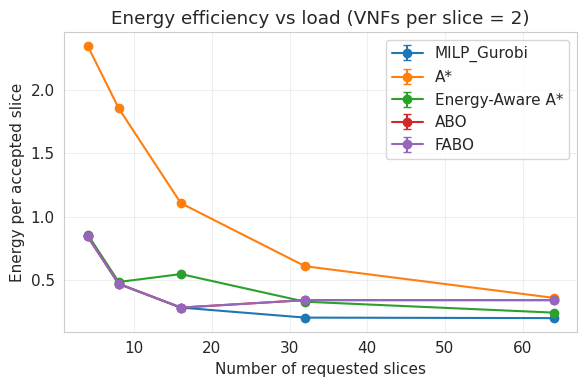

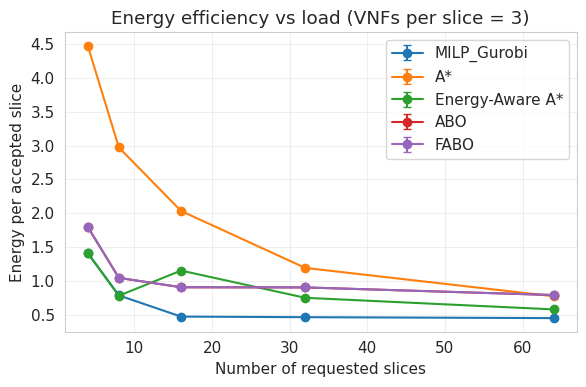

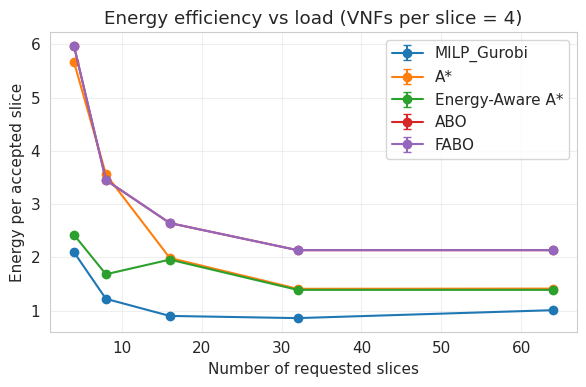

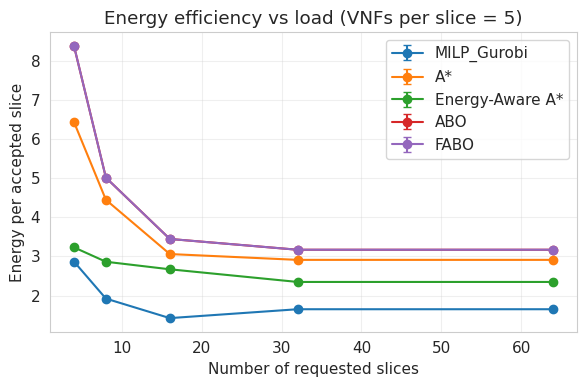

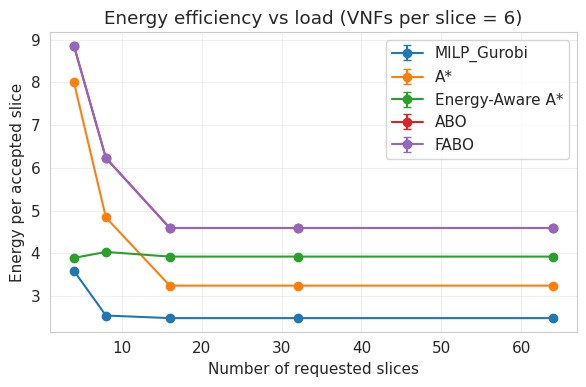

In [20]:
vnf_list = sorted(g["num_vnfs_per_slice"].unique())

for v in vnf_list:
    sub = g[g["num_vnfs_per_slice"] == v].copy()

    plt.figure(figsize=(6, 4))

    for method in present_methods:
        msub = sub[sub["method"] == method].sort_values("num_slices")
        if msub.empty:
            continue

        x = msub["num_slices"].to_numpy()
        y = msub["mean"].to_numpy()
        yerr = msub["std"].fillna(0).to_numpy()

        plt.errorbar(
            x, y,
            yerr=yerr,
            marker="o",
            linewidth=1.5,
            capsize=3,
            label=method,
        )

    plt.xlabel("Number of requested slices")
    plt.ylabel("Energy per accepted slice")
    plt.title(f"Energy efficiency vs load (VNFs per slice = {v})")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


In [21]:
import pandas as pd

df = pd.read_csv(f"{RESULTS_DIR}/scalability_results.csv")

# Normalize column names
df.columns = [c.strip().lower() for c in df.columns]

# Map common alternatives if needed
rename_map = {}
if "method" not in df.columns:
    for alt in ["methods", "algorithm", "algo", "approach", "solver"]:
        if alt in df.columns:
            rename_map[alt] = "method"
            break
if "num_slices" not in df.columns:
    for alt in ["slices", "n_slices", "requested_slices", "requested"]:
        if alt in df.columns:
            rename_map[alt] = "num_slices"
            break
if "accepted" not in df.columns:
    for alt in ["accepted_slices", "n_accepted", "accepted_count"]:
        if alt in df.columns:
            rename_map[alt] = "accepted"
            break

df = df.rename(columns=rename_map)

# Validate required columns
required_cols = {"method", "num_slices", "accepted"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Missing columns: {missing}. Available: {list(df.columns)}")

# Ensure numeric types
df["num_slices"] = pd.to_numeric(df["num_slices"], errors="coerce")
df["accepted"] = pd.to_numeric(df["accepted"], errors="coerce")

df = df.dropna(subset=["method", "num_slices", "accepted"])

# Remove First Fit e Best Fit (como já decidido)
df = df[~df["method"].isin(["First Fit", "Best Fit"])].copy()

# 100% de aceitação → accepted == num_slices
df_100 = df[df["accepted"] == df["num_slices"]].copy()

print("Cenários com 100% de aceitação:", len(df_100))


Cenários com 100% de aceitação: 2250


In [22]:
energy_agg = (
    df_100
    .groupby(["method", "num_slices"])
    .agg(
        mean_energy=("total_energy", "mean"),
        std_energy=("total_energy", "std"),
    )
    .reset_index()
)

energy_agg


,method,num_slices,mean_energy,std_energy
0,A*,4,21.534375,7.631053
1,A*,8,28.271875,8.552237
2,A*,16,32.761250,11.133149
3,A*,32,34.246458,10.904936
4,A*,64,36.286875,13.532887
5,ABO,4,20.669500,13.265695
6,ABO,8,25.934250,17.821286
7,ABO,16,29.116875,20.532221
8,ABO,32,19.945000,9.172185
9,ABO,64,21.730000,0.000000


In [23]:
import pandas as pd

df = pd.read_csv(f"{RESULTS_DIR}/scalability_results.csv")

# Defensive: normalize column names
df.columns = [c.strip().lower() for c in df.columns]

# Remove First Fit e Best Fit (como decidido)
df = df[~df["method"].isin(["first fit", "best fit"])].copy()

# Ensure numeric comparison
df["accepted"] = pd.to_numeric(df["accepted"], errors="coerce")
df["num_slices"] = pd.to_numeric(df["num_slices"], errors="coerce")

# 100% acceptance → accepted == num_slices
df_100 = df[df["accepted"] == df["num_slices"]].copy()

print("Cenários com 100% de aceitação:", len(df_100))


Cenários com 100% de aceitação: 3150


In [24]:
energy_agg = (
    df_100
    .groupby(["method", "num_vnfs_per_slice", "num_slices"])
    .agg(
        mean_energy=("total_energy", "mean"),
        std_energy=("total_energy", "std"),
    )
    .reset_index()
)

energy_agg.head()


,method,num_vnfs_per_slice,num_slices,mean_energy,std_energy
0,A*,2,4,9.4025,0.0
1,A*,2,8,14.8500,0.0
2,A*,2,16,17.7000,0.0
3,A*,2,32,19.4450,0.0
4,A*,2,64,22.8900,0.0


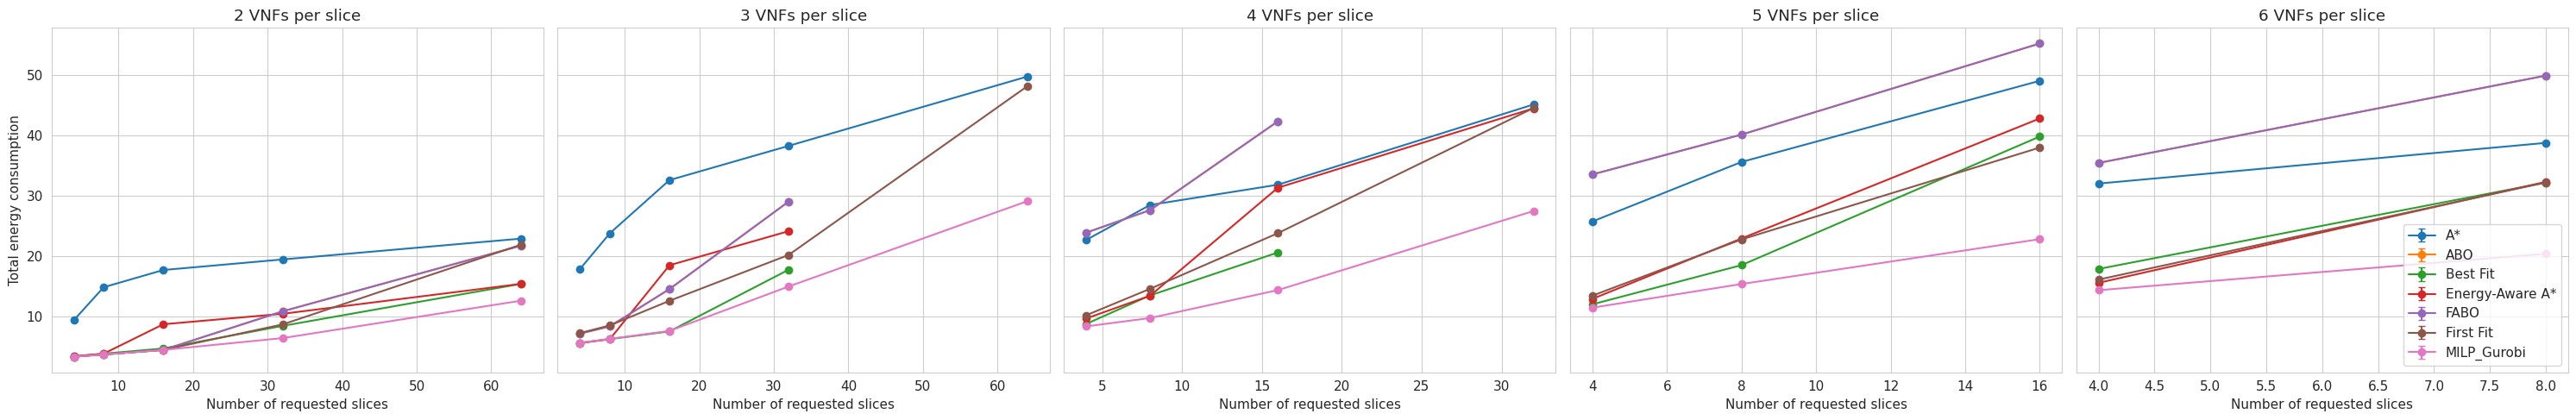

In [25]:
import matplotlib.pyplot as plt

vnf_values = sorted(energy_agg["num_vnfs_per_slice"].unique())

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(vnf_values),
    figsize=(6 * len(vnf_values), 5),
    sharey=True,
)

if len(vnf_values) == 1:
    axes = [axes]

for ax, vnf in zip(axes, vnf_values):
    sub_vnf = energy_agg[energy_agg["num_vnfs_per_slice"] == vnf]

    for method in sub_vnf["method"].unique():
        sub = sub_vnf[sub_vnf["method"] == method]

        ax.errorbar(
            sub["num_slices"],
            sub["mean_energy"],
            yerr=sub["std_energy"],
            marker="o",
            capsize=3,
            label=method,
        )

    ax.set_title(f"{vnf} VNFs per slice")
    ax.set_xlabel("Number of requested slices")
    ax.grid(True)

axes[0].set_ylabel("Total energy consumption")
axes[-1].legend()
plt.tight_layout()
plt.show()


Cenários com 100% de aceitação: 3150


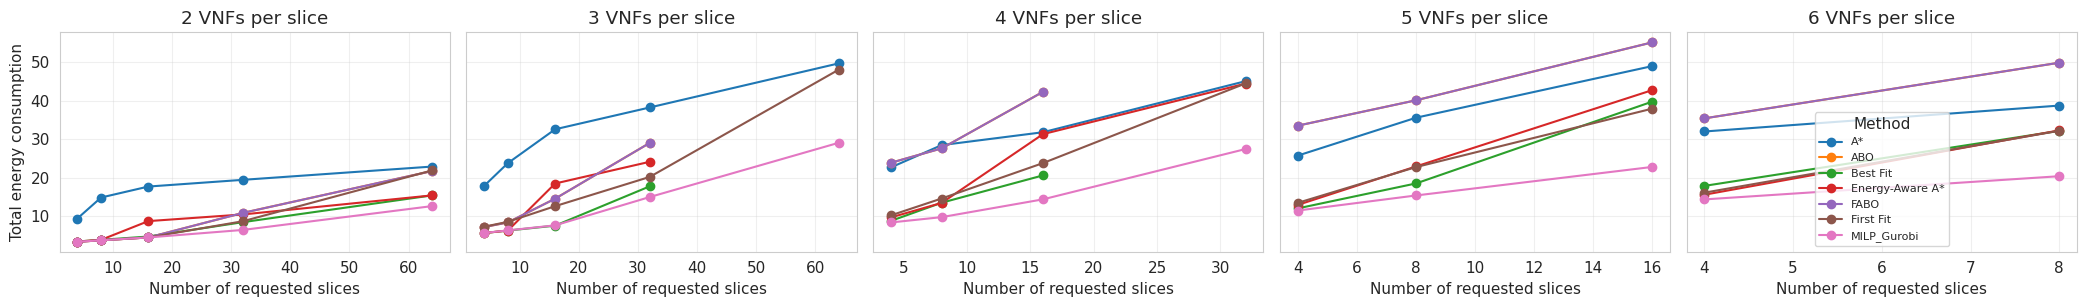

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Load results ---
df = pd.read_csv(f"{RESULTS_DIR}/scalability_results.csv")
df.columns = [c.strip().lower() for c in df.columns]

# --- Remove methods you don't want ---
methods_to_exclude = ["first fit", "best fit"]
if "method" not in df.columns:
    raise ValueError(f"Column 'method' not found. Available: {list(df.columns)}")

df = df[~df["method"].isin(methods_to_exclude)].copy()

# --- Ensure numeric types ---
for col in ["num_slices", "num_vnfs_per_slice", "total_energy", "accepted"]:
    if col not in df.columns:
        raise ValueError(f"Missing column '{col}'. Available: {list(df.columns)}")
    df[col] = pd.to_numeric(df[col], errors="coerce")

# --- Drop invalid rows ---
df = df.dropna(subset=["num_slices", "num_vnfs_per_slice", "total_energy", "method", "accepted"])

# --- Keep only 100% acceptance scenarios (fair energy comparison) ---
df_100 = df[df["accepted"] == df["num_slices"]].copy()
print("Cenários com 100% de aceitação:", len(df_100))

# --- Aggregate across seeds (mean). Change to 'median' if you prefer robustness. ---
agg = (
    df_100.groupby(["num_vnfs_per_slice", "method", "num_slices"], as_index=False)
          .agg(total_energy=("total_energy", "mean"))
)

# --- Sort for clean lines ---
agg = agg.sort_values(["num_vnfs_per_slice", "method", "num_slices"])

# --- Subplots layout (1 row like your example) ---
vnf_values = sorted(agg["num_vnfs_per_slice"].unique())
k = len(vnf_values)

fig, axes = plt.subplots(1, k, figsize=(4.2 * k, 3.2), sharey=True)
if k == 1:
    axes = [axes]

for ax, v in zip(axes, vnf_values):
    sub = agg[agg["num_vnfs_per_slice"] == v]

    for method, g in sub.groupby("method"):
        g = g.sort_values("num_slices")
        ax.plot(
            g["num_slices"],
            g["total_energy"],
            marker="o",
            label=method,
        )

    ax.set_title(f"{int(v)} VNFs per slice")
    ax.set_xlabel("Number of requested slices")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Total energy consumption")

# Legend once
axes[-1].legend(loc="best", fontsize=8, title="Method")

plt.tight_layout()
plt.show()


Cenários com 100% de aceitação: 2250


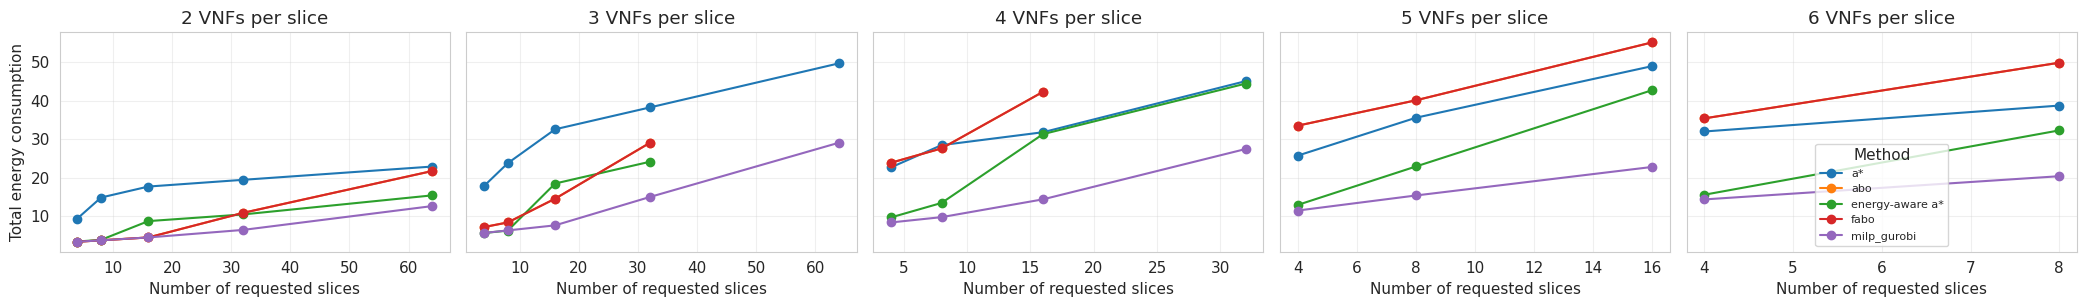

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Load results ---
df = pd.read_csv(f"{RESULTS_DIR}/scalability_results.csv")
df.columns = [c.strip().lower() for c in df.columns]

if "method" not in df.columns:
    raise ValueError(f"Column 'method' not found. Available: {list(df.columns)}")

# --- Normalize method names ---
df["method"] = df["method"].str.strip().str.lower()

# --- Exclude unwanted methods ---
exclude_keywords = [
    "first fit",
    "best fit",
]

mask_exclude = df["method"].apply(
    lambda m: any(k in m for k in exclude_keywords)
)

df = df[~mask_exclude].copy()

# --- Ensure numeric types ---
for col in ["num_slices", "num_vnfs_per_slice", "total_energy", "accepted"]:
    if col not in df.columns:
        raise ValueError(f"Missing column '{col}'. Available: {list(df.columns)}")
    df[col] = pd.to_numeric(df[col], errors="coerce")

# --- Drop invalid rows ---
df = df.dropna(subset=["num_slices", "num_vnfs_per_slice", "total_energy", "method", "accepted"])

# --- Keep only 100% acceptance scenarios ---
df_100 = df[df["accepted"] == df["num_slices"]].copy()
print("Cenários com 100% de aceitação:", len(df_100))

# --- Aggregate across seeds ---
agg = (
    df_100
    .groupby(["num_vnfs_per_slice", "method", "num_slices"], as_index=False)
    .agg(total_energy=("total_energy", "mean"))
)

agg = agg.sort_values(["num_vnfs_per_slice", "method", "num_slices"])

# --- Plot ---
vnf_values = sorted(agg["num_vnfs_per_slice"].unique())
k = len(vnf_values)

fig, axes = plt.subplots(1, k, figsize=(4.2 * k, 3.2), sharey=True)
if k == 1:
    axes = [axes]

for ax, v in zip(axes, vnf_values):
    sub = agg[agg["num_vnfs_per_slice"] == v]

    for method, g in sub.groupby("method"):
        g = g.sort_values("num_slices")
        ax.plot(
            g["num_slices"],
            g["total_energy"],
            marker="o",
            label=method,
        )

    ax.set_title(f"{int(v)} VNFs per slice")
    ax.set_xlabel("Number of requested slices")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Total energy consumption")
axes[-1].legend(loc="best", fontsize=8, title="Method")

plt.tight_layout()
plt.show()


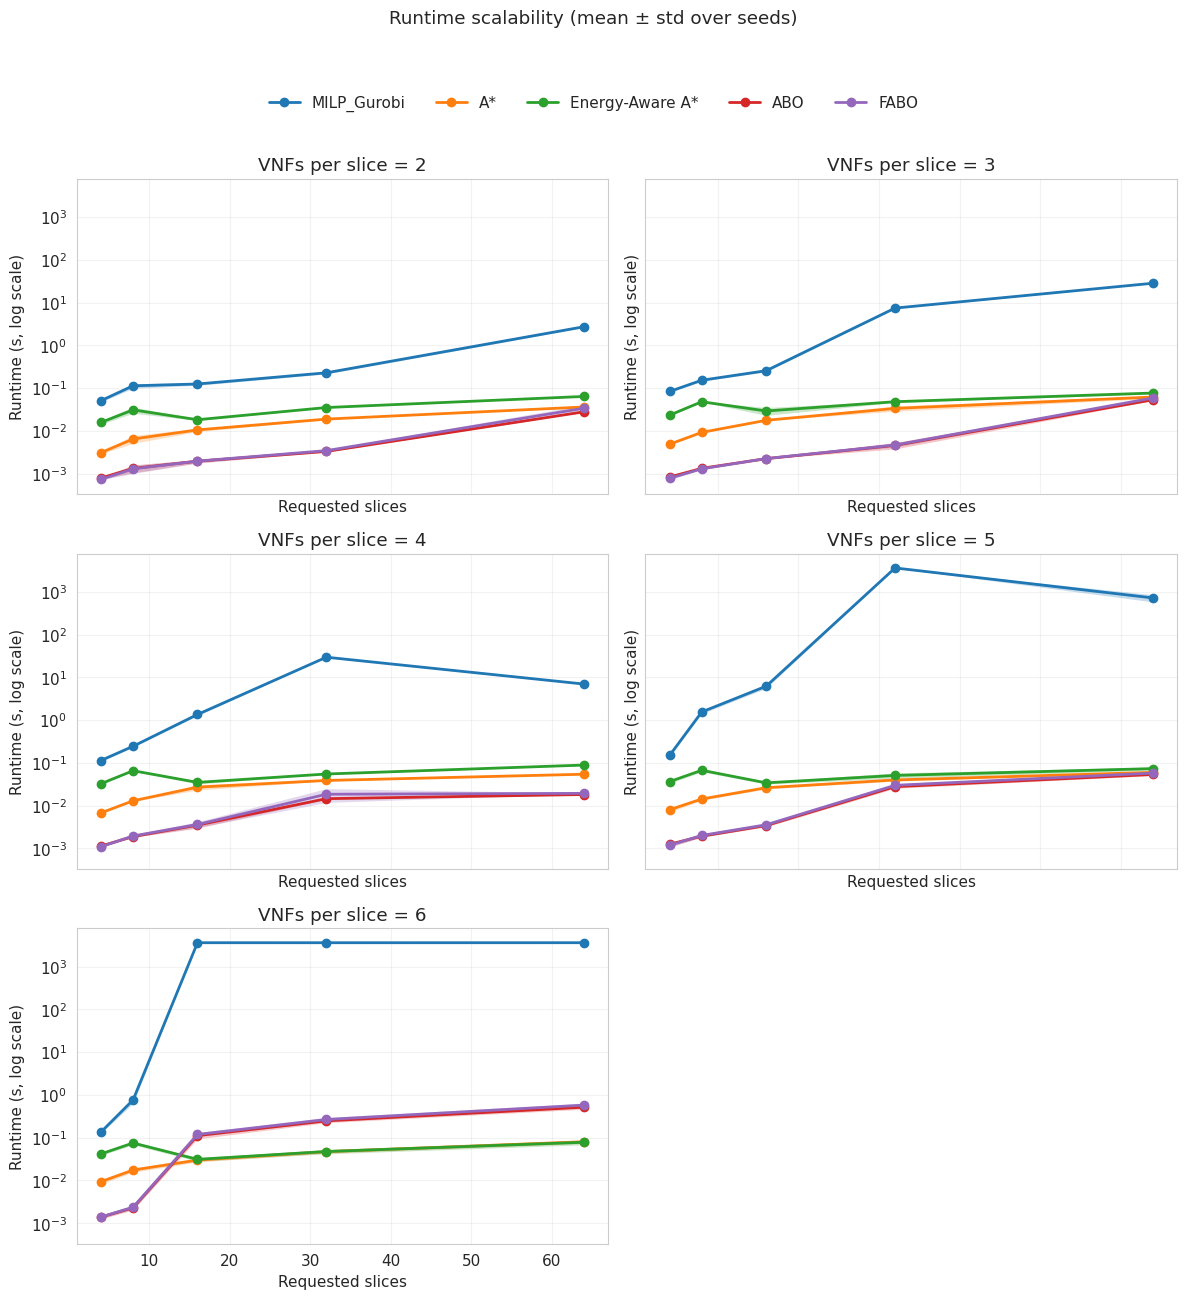

In [28]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# Prepare dataframe
# -------------------------
df = df_metrics.copy()
df.columns = [c.strip().lower() for c in df.columns]

# Remove methods not considered (keep this, but don't assume it's the only ones in your data)
methods_to_exclude = {"First Fit", "Best Fit"}
if "method" in df.columns:
    df = df[~df["method"].isin(methods_to_exclude)].copy()

# Ensure required columns exist
required_cols = {"method", "num_slices", "num_vnfs_per_slice", "runtime_sec", "seed"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {sorted(missing)}")

# Ensure numeric
for col in ["num_slices", "num_vnfs_per_slice", "runtime_sec", "seed"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Drop invalid rows
df = df.dropna(subset=["method", "num_slices", "num_vnfs_per_slice", "runtime_sec", "seed"]).copy()

# If empty after cleaning, show a clear message and stop (no crash in subplots)
if df.empty:
    plt.figure(figsize=(7, 3))
    plt.text(
        0.5, 0.5,
        "No data to plot after cleaning.\nCheck method names / filters / required columns.",
        ha="center", va="center"
    )
    plt.axis("off")
    plt.show()
else:
    # -------------------------
    # Aggregate per seed
    # -------------------------
    scenario_runtime = (
        df.groupby(["num_vnfs_per_slice", "method", "num_slices", "seed"], as_index=False)
          .agg(runtime_sec=("runtime_sec", "mean"))
    )

    # -------------------------
    # Aggregate across seeds: mean + std
    # -------------------------
    runtime_agg = (
        scenario_runtime.groupby(["num_vnfs_per_slice", "method", "num_slices"], as_index=False)
          .agg(
              mean_runtime=("runtime_sec", "mean"),
              std_runtime=("runtime_sec", "std"),
          )
    )

    # Std can be NaN if only 1 seed -> set to 0
    runtime_agg["std_runtime"] = runtime_agg["std_runtime"].fillna(0.0)

    # If still empty, show message and stop
    if runtime_agg.empty:
        plt.figure(figsize=(7, 3))
        plt.text(
            0.5, 0.5,
            "No aggregated data to plot.\nCheck if runtime_sec exists and seeds are present.",
            ha="center", va="center"
        )
        plt.axis("off")
        plt.show()
    else:
        # Stable ordering (only keep what exists)
        method_order = ["MILP_Gurobi", "A*", "Energy-Aware A*", "ABO", "FABO"]
        present = [m for m in method_order if m in runtime_agg["method"].unique()]
        if not present:
            # Fallback: use whatever is present, sorted
            present = sorted(runtime_agg["method"].unique())

        runtime_agg = runtime_agg[runtime_agg["method"].isin(present)].copy()
        runtime_agg["method"] = pd.Categorical(runtime_agg["method"], categories=present, ordered=True)

        vnf_order = sorted(runtime_agg["num_vnfs_per_slice"].unique())
        runtime_agg["num_vnfs_per_slice"] = pd.Categorical(
            runtime_agg["num_vnfs_per_slice"], categories=vnf_order, ordered=True
        )

        # Dynamic grid
        n_panels = len(vnf_order)
        ncols = 2 if n_panels > 1 else 1
        nrows = math.ceil(n_panels / ncols)

        fig, axes = plt.subplots(
            nrows, ncols,
            figsize=(12 if ncols == 2 else 7, 4 * nrows),
            sharex=True,
            sharey=True
        )
        if isinstance(axes, np.ndarray):
            axes = axes.flatten()
        else:
            axes = [axes]

        # Fixed colors per method using Matplotlib default cycle
        default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
        method_color = {m: default_colors[i % len(default_colors)] for i, m in enumerate(present)}

        for idx, num_vnfs in enumerate(vnf_order):
            ax = axes[idx]
            df_v = runtime_agg[runtime_agg["num_vnfs_per_slice"] == num_vnfs].copy()

            for method in present:
                df_m = df_v[df_v["method"] == method].copy()
                if df_m.empty:
                    continue

                df_m = df_m.sort_values("num_slices")
                x = df_m["num_slices"].to_numpy(dtype=float)
                y = df_m["mean_runtime"].to_numpy(dtype=float)
                y_std = df_m["std_runtime"].to_numpy(dtype=float)

                ax.plot(
                    x, y,
                    marker="o",
                    linewidth=2,
                    label=method if idx == 0 else None,
                    color=method_color[method],
                )
                ax.fill_between(
                    x,
                    y - y_std,
                    y + y_std,
                    alpha=0.25,
                    color=method_color[method],
                    linewidth=0,
                )

            ax.set_title(f"VNFs per slice = {int(num_vnfs)}")
            ax.set_yscale("log")
            ax.grid(True, alpha=0.25)
            ax.set_xlabel("Requested slices")
            ax.set_ylabel("Runtime (s, log scale)")

        # Hide unused axes
        for j in range(n_panels, len(axes)):
            axes[j].set_visible(False)

        # Global legend
        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(
            handles,
            labels,
            loc="upper center",
            ncol=min(len(labels), 5),
            frameon=False,
            bbox_to_anchor=(0.5, 1.02),
        )

        fig.suptitle("Runtime scalability (mean ± std over seeds)", y=1.08)
        plt.tight_layout()
        plt.show()


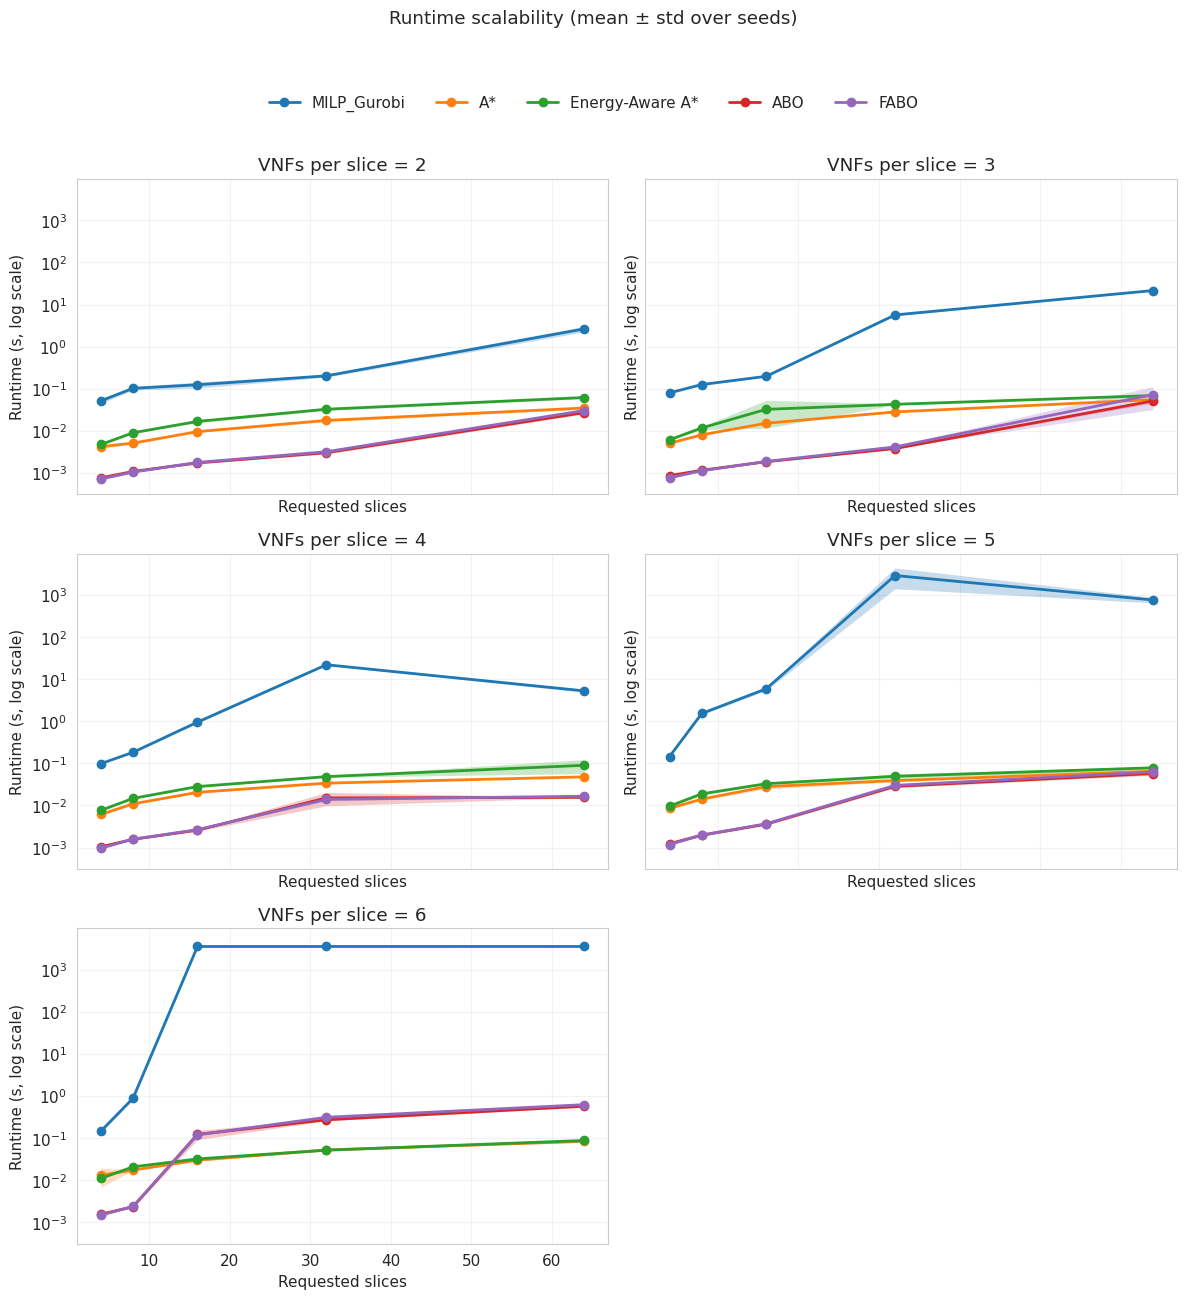

In [15]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Prepare dataframe
# =========================
df = df_metrics.copy()
df.columns = [c.strip().lower() for c in df.columns]

required_cols = {"method", "num_slices", "num_vnfs_per_slice", "runtime_sec", "seed"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {sorted(missing)}")

# -------------------------
# Robust exclusion of First Fit and Best Fit
# -------------------------
df["method_norm"] = (
    df["method"].astype(str)
      .str.strip()
      .str.lower()
      .str.replace(r"[\s\-_]+", " ", regex=True)
)

exclude_norm = {"first fit", "best fit"}
df = df[~df["method_norm"].isin(exclude_norm)].copy()
df = df.drop(columns=["method_norm"])

# -------------------------
# Ensure numeric
# -------------------------
for col in ["num_slices", "num_vnfs_per_slice", "runtime_sec", "seed"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["method", "num_slices", "num_vnfs_per_slice", "runtime_sec", "seed"]).copy()

if df.empty:
    plt.figure(figsize=(6,3))
    plt.text(0.5, 0.5, "No data after filtering.", ha="center", va="center")
    plt.axis("off")
    plt.show()

else:

    # =========================
    # Aggregate per seed
    # =========================
    scenario_runtime = (
        df.groupby(["num_vnfs_per_slice", "method", "num_slices", "seed"], as_index=False)
          .agg(runtime_sec=("runtime_sec", "mean"))
    )

    # =========================
    # Aggregate across seeds
    # =========================
    runtime_agg = (
        scenario_runtime.groupby(["num_vnfs_per_slice", "method", "num_slices"], as_index=False)
          .agg(
              mean_runtime=("runtime_sec", "mean"),
              std_runtime=("runtime_sec", "std"),
          )
    )

    runtime_agg["std_runtime"] = runtime_agg["std_runtime"].fillna(0.0)

    if runtime_agg.empty:
        plt.figure(figsize=(6,3))
        plt.text(0.5, 0.5, "No aggregated data to plot.", ha="center", va="center")
        plt.axis("off")
        plt.show()

    else:

        # Stable ordering
        method_order = ["MILP_Gurobi", "A*", "Energy-Aware A*", "ABO", "FABO"]
        present = [m for m in method_order if m in runtime_agg["method"].unique()]
        if not present:
            present = sorted(runtime_agg["method"].unique())

        runtime_agg = runtime_agg[runtime_agg["method"].isin(present)].copy()
        runtime_agg["method"] = pd.Categorical(runtime_agg["method"], categories=present, ordered=True)

        vnf_order = sorted(runtime_agg["num_vnfs_per_slice"].unique())
        runtime_agg["num_vnfs_per_slice"] = pd.Categorical(
            runtime_agg["num_vnfs_per_slice"], categories=vnf_order, ordered=True
        )

        # =========================
        # Plot
        # =========================
        n_panels = len(vnf_order)
        ncols = 2 if n_panels > 1 else 1
        nrows = math.ceil(n_panels / ncols)

        fig, axes = plt.subplots(
            nrows, ncols,
            figsize=(12 if ncols == 2 else 7, 4 * nrows),
            sharex=True,
            sharey=True
        )

        if isinstance(axes, np.ndarray):
            axes = axes.flatten()
        else:
            axes = [axes]

        default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
        method_color = {m: default_colors[i % len(default_colors)] for i, m in enumerate(present)}

        for idx, num_vnfs in enumerate(vnf_order):
            ax = axes[idx]
            df_v = runtime_agg[runtime_agg["num_vnfs_per_slice"] == num_vnfs].copy()

            for method in present:
                df_m = df_v[df_v["method"] == method].copy()
                if df_m.empty:
                    continue

                df_m = df_m.sort_values("num_slices")
                x = df_m["num_slices"].to_numpy(dtype=float)
                y = df_m["mean_runtime"].to_numpy(dtype=float)
                y_std = df_m["std_runtime"].to_numpy(dtype=float)

                ax.plot(
                    x, y,
                    marker="o",
                    linewidth=2,
                    label=method if idx == 0 else None,
                    color=method_color[method],
                )

                ax.fill_between(
                    x,
                    y - y_std,
                    y + y_std,
                    alpha=0.25,
                    color=method_color[method],
                    linewidth=0,
                )

            ax.set_title(f"VNFs per slice = {int(num_vnfs)}")
            ax.set_yscale("log")
            ax.grid(True, alpha=0.25)
            ax.set_xlabel("Requested slices")
            ax.set_ylabel("Runtime (s, log scale)")

        # Hide unused axes
        for j in range(n_panels, len(axes)):
            axes[j].set_visible(False)

        # Global legend
        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(
            handles,
            labels,
            loc="upper center",
            ncol=min(len(labels), 5),
            frameon=False,
            bbox_to_anchor=(0.5, 1.02),
        )

        fig.suptitle("Runtime scalability (mean ± std over seeds)", y=1.08)
        plt.tight_layout()
        plt.show()


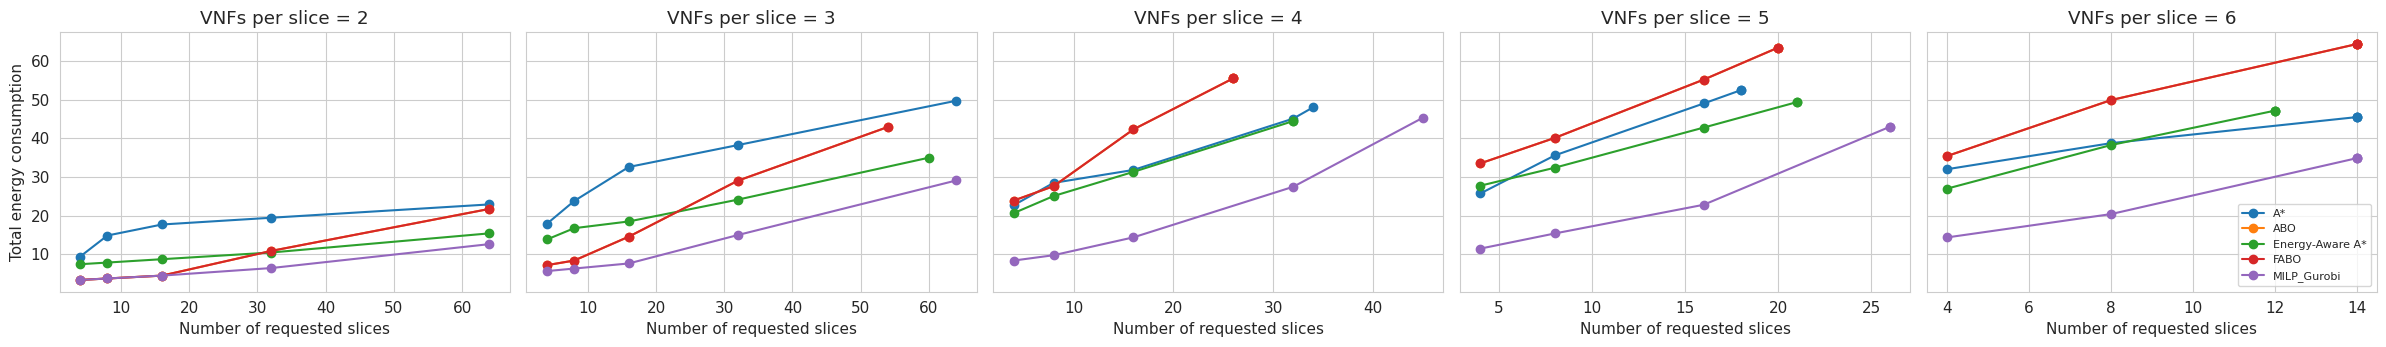

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Load results

df = pd.read_csv(f"{RESULTS_DIR}/scalability_results.csv")

# Optional: remove methods you don't want
methods_to_exclude = ["First Fit", "Best Fit"]
df = df[~df["method"].isin(methods_to_exclude)].copy()

# Ensure numeric types
df["num_slices"] = pd.to_numeric(df["num_slices"], errors="coerce")
df["num_vnfs_per_slice"] = pd.to_numeric(df["num_vnfs_per_slice"], errors="coerce")
df["accepted"] = pd.to_numeric(df["accepted"], errors="coerce")
df["total_energy"] = pd.to_numeric(df["total_energy"], errors="coerce")

df = df.dropna(subset=["num_vnfs_per_slice", "method", "accepted", "total_energy"])

# Aggregate across seeds (mean) per (vnfs, method, num_slices)
agg = (
    df.groupby(["num_vnfs_per_slice", "method", "num_slices"], as_index=False)
      .agg(
          accepted=("accepted", "mean"),
          total_energy=("total_energy", "mean"),
      )
)

# Sort and build subplots like your example
vnf_values = sorted(agg["num_vnfs_per_slice"].unique())
k = len(vnf_values)

fig, axes = plt.subplots(1, k, figsize=(4.8 * k, 3.6), sharey=True)

if k == 1:
    axes = [axes]

for ax, v in zip(axes, vnf_values):
    sub = agg[agg["num_vnfs_per_slice"] == v].copy()

    for method, g in sub.groupby("method"):
        g = g.sort_values("accepted")
        ax.plot(
            g["accepted"],
            g["total_energy"],
            marker="o",
            label=method,
        )

    ax.set_title(f"VNFs per slice = {int(v)}")
    ax.set_xlabel("Number of requested slices")
    ax.grid(True)

axes[0].set_ylabel("Total energy consumption")
axes[-1].legend(loc="best", fontsize=8)

plt.tight_layout()
plt.show()


In [25]:

df = pd.read_csv(f"{RESULTS_DIR}/scalability_results.csv")

# Remove First Fit e Best Fit (como já decidido)
df = df[~df["method"].isin(["First Fit", "Best Fit"])].copy()

# 100% de aceitação → accepted == num_slices
df_100 = df[df["accepted"] == df["num_slices"]].copy()

print("Cenários com 100% de aceitação:", len(df_100))


KeyError: 'method'

In [48]:
energy_agg = (
    df_100
    .groupby(["method", "num_vnfs_per_slice", "num_slices"])
    .agg(
        mean_energy=("total_energy", "mean"),
        std_energy=("total_energy", "std"),
    )
    .reset_index()
)

energy_agg


,method,num_vnfs_per_slice,num_slices,mean_energy,std_energy
0,A*,2,4,9.4025,0.0
1,A*,2,8,14.8500,0.0
2,A*,2,16,17.7000,0.0
3,A*,2,32,19.4450,0.0
4,A*,2,64,22.8900,0.0
...,...,...,...,...,...
64,MILP_Gurobi,5,4,11.4725,0.0
65,MILP_Gurobi,5,8,15.3850,0.0
66,MILP_Gurobi,5,16,22.8000,0.0
67,MILP_Gurobi,6,4,14.3625,0.0


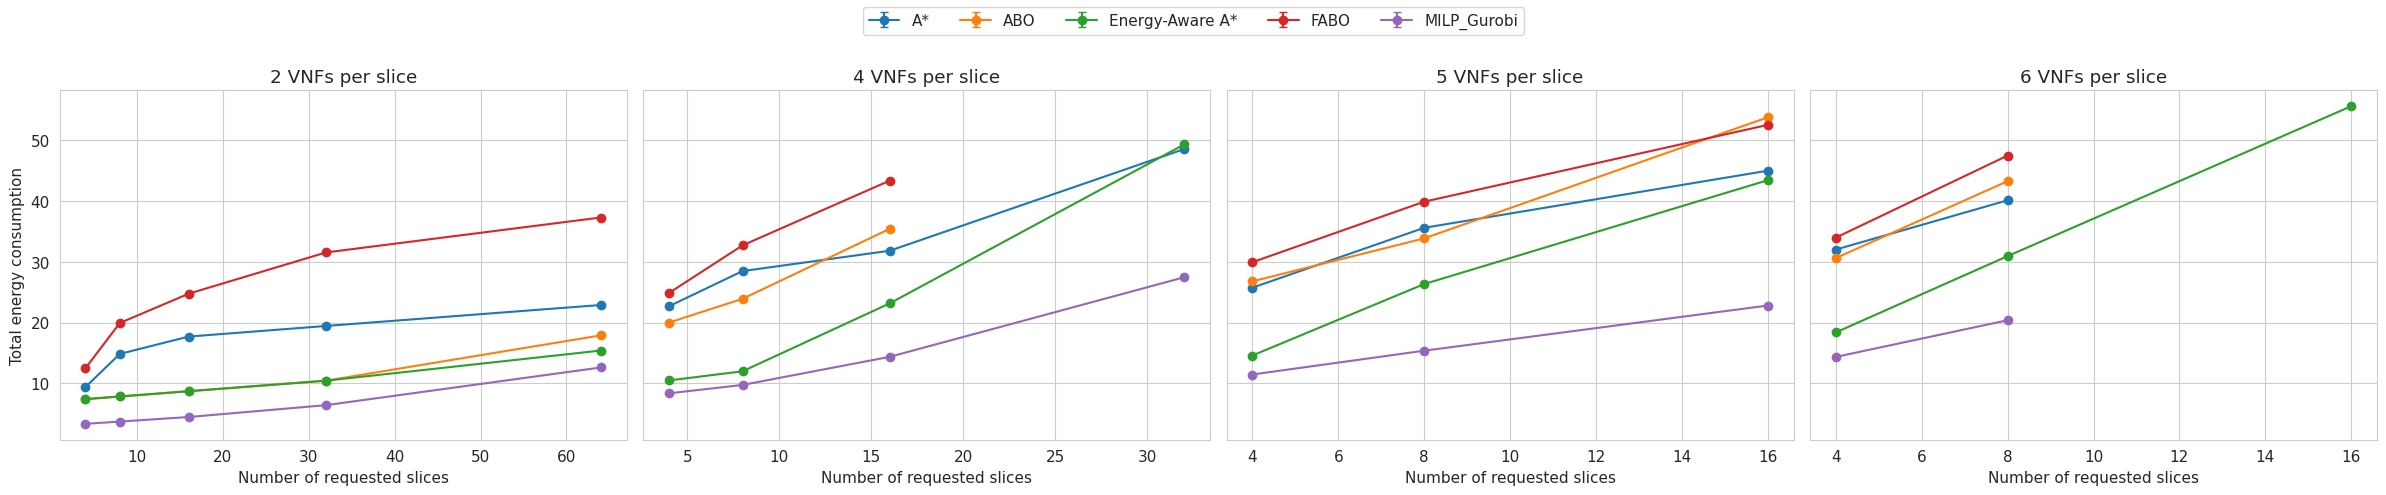

In [49]:
import matplotlib.pyplot as plt

vnf_values = sorted(energy_agg["num_vnfs_per_slice"].unique())

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(vnf_values),
    figsize=(6 * len(vnf_values), 5),
    sharey=True,
)

# Ensure axes is iterable
if len(vnf_values) == 1:
    axes = [axes]

for ax, vnf in zip(axes, vnf_values):
    sub_vnf = energy_agg[energy_agg["num_vnfs_per_slice"] == vnf]

    for method in sub_vnf["method"].unique():
        sub = sub_vnf[sub_vnf["method"] == method]

        ax.errorbar(
            sub["num_slices"],
            sub["mean_energy"],
            yerr=sub["std_energy"],
            marker="o",
            capsize=3,
            label=method,  # Label must be set for legend
        )

    ax.set_title(f"{vnf} VNFs per slice")
    ax.set_xlabel("Number of requested slices")
    ax.grid(True)

axes[0].set_ylabel("Total energy consumption")

# --- GLOBAL legend (fixes missing MILP) ---
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=len(labels),
)

plt.tight_layout(rect=[0, 0, 1, 0.90])  # Leave space for legend
plt.show()


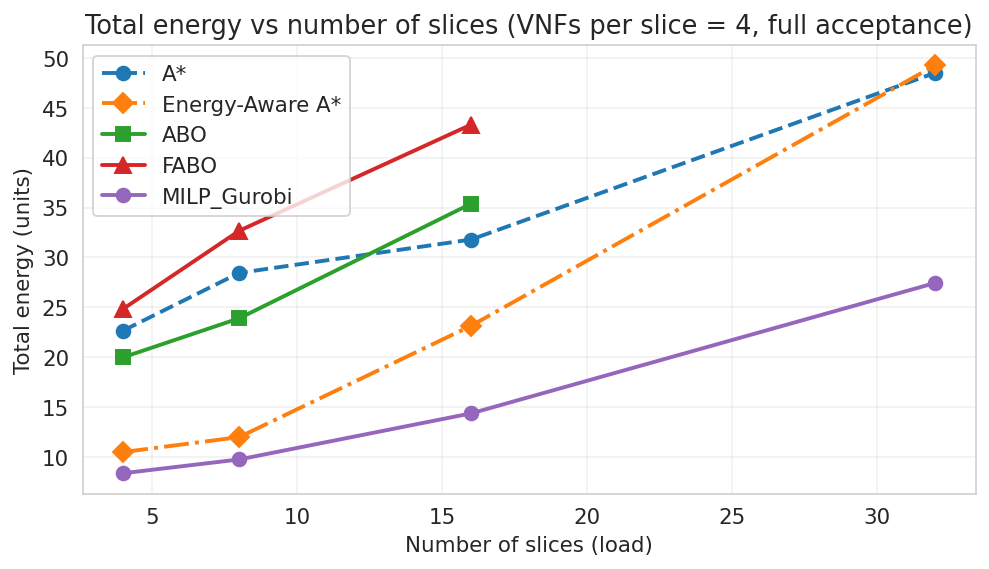

In [71]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Load results ---
df = pd.read_csv(f"{RESULTS_DIR}/scalability_results.csv")
df.columns = [c.strip().lower() for c in df.columns]

# --- Basic checks ---
required = {"method", "num_slices", "num_vnfs_per_slice", "total_energy", "accepted"}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Missing columns: {missing}. Available: {list(df.columns)}")

# --- Normalize method names ---
df["method"] = df["method"].astype(str).str.strip().str.lower()

# --- Numeric conversion ---
for col in ["num_slices", "num_vnfs_per_slice", "total_energy", "accepted"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df = df.dropna(subset=["num_slices", "num_vnfs_per_slice", "total_energy", "accepted", "method"])

# --- Keep VNFs per slice = 4 and full acceptance ---
df4 = df[(df["num_vnfs_per_slice"] == 4) & (df["accepted"] == df["num_slices"])].copy()
if df4.empty:
    raise ValueError("No data found for VNFs per slice = 4 with full acceptance (accepted == num_slices).")

# --- Map method names to plot labels (robust) ---
def map_method(m: str) -> str | None:
    m = m.lower()

    # MILP (covers: milp, gurobi, milp_gurobi, etc.)
    if "milp" in m or "gurobi" in m:
        return "MILP_Gurobi"

    # FABO / ABO
    if "fabo" in m:
        return "FABO"
    if m.strip() == "abo" or " abo" in f" {m} ":
        return "ABO"

    # Energy-Aware A*
    if "energy" in m and "a*" in m:
        return "Energy-Aware A*"

    # Plain A*
    if "a*" in m and "energy" not in m:
        return "A*"

    return None

df4["method_plot"] = df4["method"].apply(map_method)
df4 = df4.dropna(subset=["method_plot"])

# --- Aggregate across seeds (mean) ---
agg = (
    df4.groupby(["num_slices", "method_plot"], as_index=False)
       .agg(total_energy=("total_energy", "mean"))
       .sort_values(["num_slices", "method_plot"])
)

# --- Plot styles (similar to your example) ---
styles = {
    "A*": dict(marker="o", linestyle="--", linewidth=2, markersize=7),
    "ABO": dict(marker="s", linestyle="-",  linewidth=2, markersize=7),
    "FABO": dict(marker="^", linestyle="-",  linewidth=2, markersize=8),
    "Energy-Aware A*": dict(marker="D", linestyle="-.", linewidth=2, markersize=7),
    "MILP_Gurobi": dict(marker="o", linestyle="-", linewidth=2, markersize=7),
}

order = ["A*", "Energy-Aware A*", "ABO", "FABO", "MILP_Gurobi"]

plt.figure(figsize=(7.2, 4.2), dpi=140)

for method in order:
    sub = agg[agg["method_plot"] == method].sort_values("num_slices")
    if sub.empty:
        continue
    plt.plot(
        sub["num_slices"],
        sub["total_energy"],
        label=method,
        **styles.get(method, {}),
    )

plt.title("Total energy vs number of slices (VNFs per slice = 4, full acceptance)")
plt.xlabel("Number of slices (load)")
plt.ylabel("Total energy (units)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


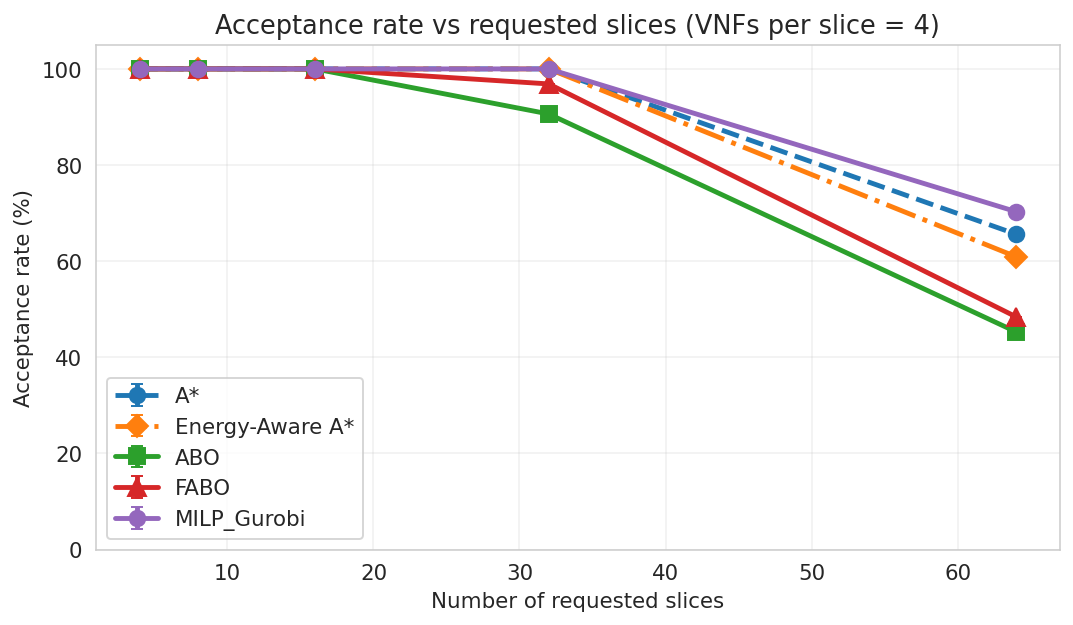

In [73]:
import pandas as pd
import matplotlib.pyplot as plt

VNF_TARGET = 4

# --- Style spec (match your energy plot) ---
STYLE = {
    "A*":               dict(color="#1f77b4", marker="o", linestyle="--", linewidth=2.5, markersize=8),
    "Energy-Aware A*":  dict(color="#ff7f0e", marker="D", linestyle="-.", linewidth=2.5, markersize=8),
    "ABO":              dict(color="#2ca02c", marker="s", linestyle="-",  linewidth=2.5, markersize=8),
    "FABO":             dict(color="#d62728", marker="^", linestyle="-",  linewidth=2.5, markersize=9),
    "MILP_Gurobi":      dict(color="#9467bd", marker="o", linestyle="-",  linewidth=2.5, markersize=8),
}
ORDER = ["A*", "Energy-Aware A*", "ABO", "FABO", "MILP_Gurobi"]

# --- Load ---
df = pd.read_csv(f"{RESULTS_DIR}/scalability_results.csv")
df.columns = [c.strip().lower() for c in df.columns]

# --- Checks ---
required = {"method", "num_slices", "num_vnfs_per_slice", "accepted"}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Missing columns: {missing}. Available: {list(df.columns)}")

# --- Normalize ---
df["method"] = df["method"].astype(str).str.strip()
df["method_norm"] = df["method"].str.lower().str.strip()

# --- Numeric ---
for col in ["num_slices", "num_vnfs_per_slice", "accepted"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df = df.dropna(subset=["num_slices", "num_vnfs_per_slice", "accepted", "method_norm"])

# --- Acceptance rate (%)
df["acceptance_rate"] = 100.0 * df["accepted"] / df["num_slices"]

# --- Filter VNFs per slice ---
df = df[df["num_vnfs_per_slice"] == VNF_TARGET].copy()
if df.empty:
    raise ValueError(f"No rows for num_vnfs_per_slice == {VNF_TARGET}")

def map_method(m: str) -> str | None:
    # English comment: map raw method names to canonical plot labels
    m = m.lower()
    if "milp" in m or "gurobi" in m:
        return "MILP_Gurobi"
    if "energy" in m and "a*" in m:
        return "Energy-Aware A*"
    if "fabo" in m:
        return "FABO"
    if m.strip() == "abo" or " abo" in f" {m} ":
        return "ABO"
    if "a*" in m and "energy" not in m:
        return "A*"
    return None

df["method_plot"] = df["method_norm"].apply(map_method)
df = df.dropna(subset=["method_plot"]).copy()

# --- Aggregate across seeds: mean + std ---
g = (
    df.groupby(["num_slices", "method_plot"])["acceptance_rate"]
      .agg(["mean", "std", "count"])
      .reset_index()
      .sort_values(["method_plot", "num_slices"])
)

# --- Plot ---
plt.figure(figsize=(7.8, 4.6), dpi=140)

for method in ORDER:
    msub = g[g["method_plot"] == method].sort_values("num_slices")
    if msub.empty:
        continue

    x = msub["num_slices"].to_numpy()
    y = msub["mean"].to_numpy()
    yerr = msub["std"].fillna(0).to_numpy()

    plt.errorbar(
        x, y, yerr=yerr,
        capsize=3,
        label=method,
        **STYLE[method],
    )

plt.title(f"Acceptance rate vs requested slices (VNFs per slice = {VNF_TARGET})")
plt.xlabel("Number of requested slices")
plt.ylabel("Acceptance rate (%)")
plt.ylim(0, 105)
plt.grid(True, alpha=0.3)
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()


In [57]:
# --- Normalize method names ---
df["method"] = df["method"].str.strip().str.lower()

# --- Remove energy-aware methods ---
df = df[~df["method"].str.contains("energy", case=False, regex=True)].copy()


In [65]:
df = pd.read_csv(f"{RESULTS_DIR}/scalability_results.csv")

# Remove First Fit, Best Fit e Energy-Aware
df["method"] = df["method"].str.strip().str.lower()
df = df[~df["method"].str.contains("first fit|best fit|energy", regex=True)].copy()

# Ensure numeric
df["accepted"] = pd.to_numeric(df["accepted"], errors="coerce")
df["num_slices"] = pd.to_numeric(df["num_slices"], errors="coerce")
df["num_vnfs_per_slice"] = pd.to_numeric(df["num_vnfs_per_slice"], errors="coerce")

# Acceptance rate in %
df["acceptance_rate"] = 100.0 * df["accepted"] / df["num_slices"]


In [67]:
g = (
    df.groupby(["num_vnfs_per_slice", "num_slices", "method"])["acceptance_rate"]
      .agg(["mean", "std", "count"])
      .reset_index()
)


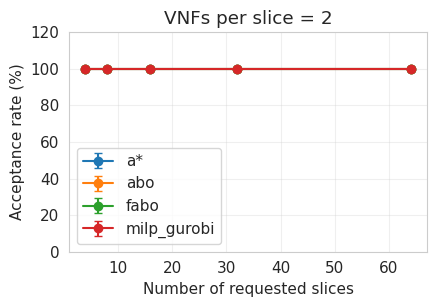

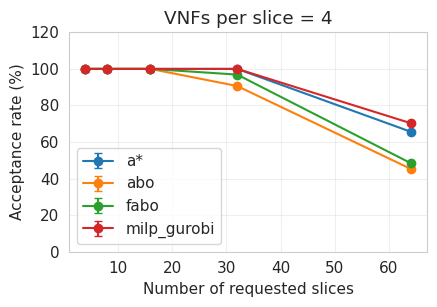

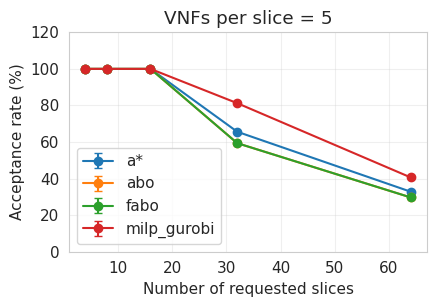

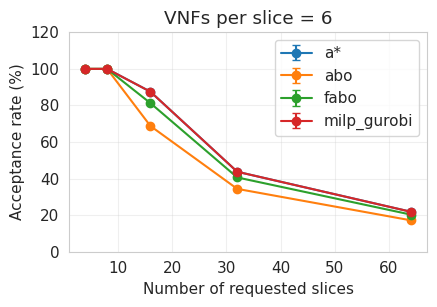

In [69]:
vnf_list = sorted(g["num_vnfs_per_slice"].unique())

for v in vnf_list:
    sub = g[g["num_vnfs_per_slice"] == v]

    plt.figure(figsize=(4.5, 3.2))
    for method, msub in sub.groupby("method"):
        msub = msub.sort_values("num_slices")

        plt.errorbar(
            msub["num_slices"],
            msub["mean"],
            yerr=msub["std"].fillna(0),
            marker="o",
            linewidth=1.5,
            capsize=3,
            label=method,
        )

    plt.xlabel("Number of requested slices")
    plt.ylabel("Acceptance rate (%)")
    plt.title(f"VNFs per slice = {v}")
    plt.ylim(0, 120)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


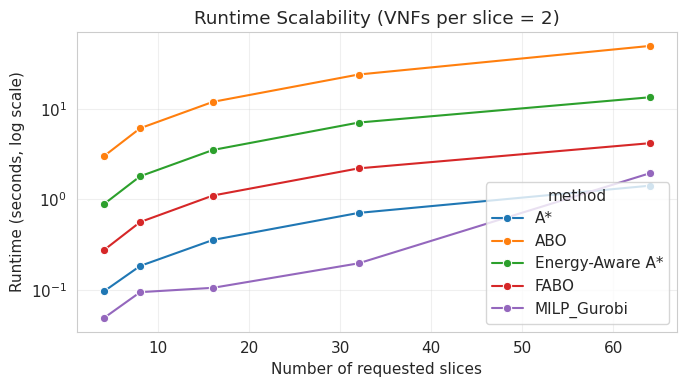

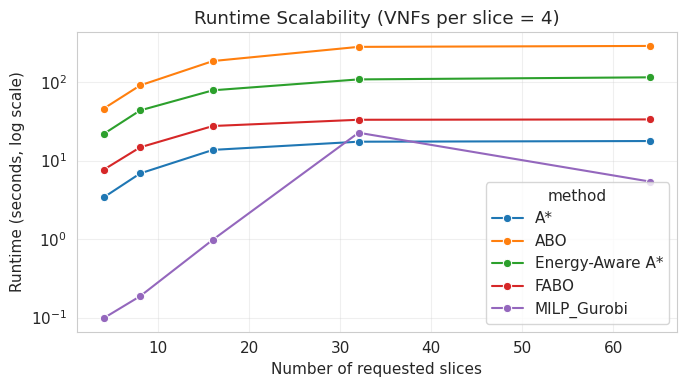

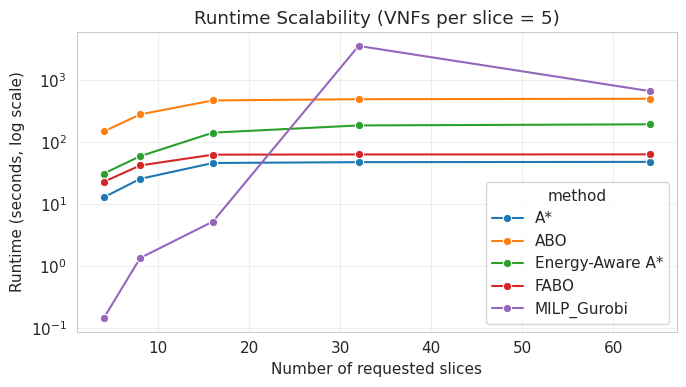

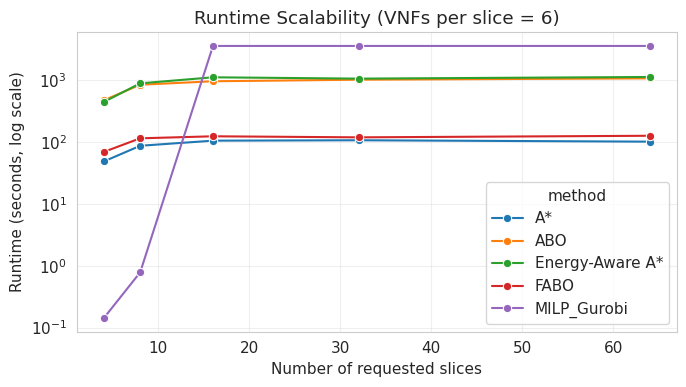

In [55]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Defensive copy
df = df_metrics.copy()
df.columns = [c.strip().lower() for c in df.columns]

# Remove methods not considered
methods_to_exclude = {"First Fit", "Best Fit"}
df = df[~df["method"].isin(methods_to_exclude)].copy()

# Ensure numeric
for col in ["num_slices", "num_vnfs_per_slice", "runtime_sec", "seed"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Drop invalid rows
df = df.dropna(subset=["method", "num_slices", "num_vnfs_per_slice", "runtime_sec", "seed"])

# --- Aggregate runtime per scenario (method, slices, seed) ---
scenario_runtime = (
    df.groupby(
        ["num_vnfs_per_slice", "method", "num_slices", "seed"],
        as_index=False
    )
    .agg(runtime_sec=("runtime_sec", "mean"))
)

# --- Aggregate across seeds (mean runtime) ---
runtime_agg = (
    scenario_runtime.groupby(
        ["num_vnfs_per_slice", "method", "num_slices"],
        as_index=False
    )
    .agg(mean_runtime=("runtime_sec", "mean"))
)

runtime_agg = runtime_agg.sort_values(
    ["num_vnfs_per_slice", "method", "num_slices"]
)

# --- Plot: one figure per VNF-per-slice scenario ---
for num_vnfs, df_vnf in runtime_agg.groupby("num_vnfs_per_slice"):
    plt.figure(figsize=(7, 4))

    sns.lineplot(
        data=df_vnf,
        x="num_slices",
        y="mean_runtime",
        hue="method",
        marker="o",
    )

    plt.yscale("log")
    plt.xlabel("Number of requested slices")
    plt.ylabel("Runtime (seconds, log scale)")
    plt.title(f"Runtime Scalability (VNFs per slice = {int(num_vnfs)})")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    plt.show()


In [2]:
import math
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter


In [6]:
# Physical topology graph
G = nx.Graph()

# Nodes with CPU capacity (vCPU)
node_cpu = {1: 10, 2: 10, 3: 10, 4: 10, 5: 10}
G.add_nodes_from(node_cpu.keys())

# Edges with bandwidth (Mbps) and latency (ms)
# Matching the example image
edges = [
    (5, 4, {"bw": 100, "lat": 5}),
    (4, 1, {"bw": 100, "lat": 5}),
    (1, 2, {"bw": 5,   "lat": 2}),
    (2, 3, {"bw": 5,   "lat": 2}),
    (3, 5, {"bw": 5,   "lat": 2}),
    (4, 2, {"bw": 50,  "lat": 1}),
]
G.add_edges_from([(u, v, d) for u, v, d in edges])

# Fixed positions to resemble the layout in the reference
pos = {
    5: (0.0, 0.0),
    4: (1.0, 1.0),
    1: (2.2, 1.4),
    2: (2.0, 0.5),
    3: (1.0, -0.7),
}



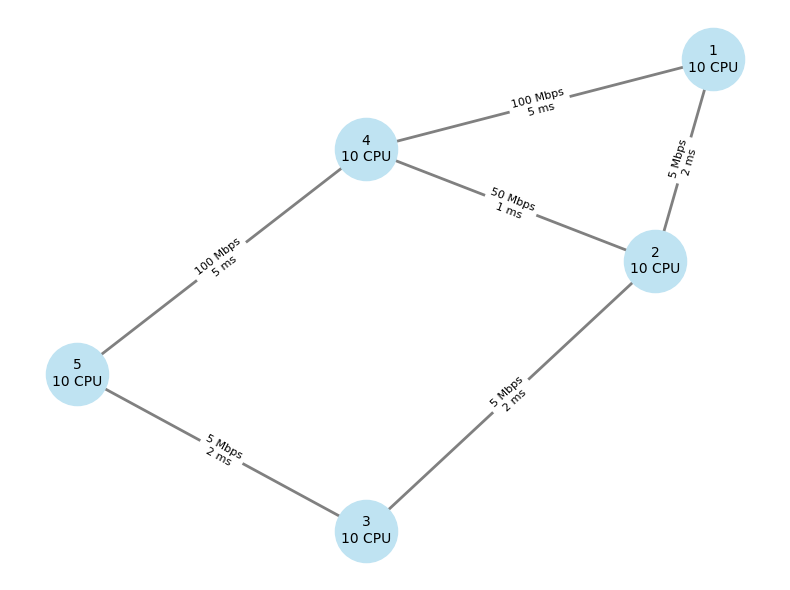

In [19]:
import matplotlib.pyplot as plt
import networkx as nx

# Physical topology graph
G = nx.Graph()

# Nodes with CPU capacity (vCPU)
node_cpu = {1: 10, 2: 10, 3: 10, 4: 10, 5: 10}
G.add_nodes_from(node_cpu.keys())

# Edges with bandwidth (Mbps) and latency (ms)
edges = [
    (5, 4, {"bw": 100, "lat": 5}),
    (4, 1, {"bw": 100, "lat": 5}),
    (1, 2, {"bw": 5,   "lat": 2}),
    (2, 3, {"bw": 5,   "lat": 2}),
    (3, 5, {"bw": 5,   "lat": 2}),
    (4, 2, {"bw": 50,  "lat": 1}),
]

G.add_edges_from([(u, v, d) for u, v, d in edges])

# Fixed positions
pos = {
    5: (0.0, 0.0),
    4: (1.0, 1.0),
    1: (2.2, 1.4),
    2: (2.0, 0.5),
    3: (1.0, -0.7),
}

plt.figure(figsize=(8, 6))

# Draw nodes with custom color
nx.draw_networkx_nodes(
    G,
    pos,
    node_size=2000,
    node_color="#bfe3f2",
    #edgecolors="black",  # border for better visibility
)

# Draw edges
nx.draw_networkx_edges(
    G,
    pos,
    width=2,
    edge_color="gray",
)

# Node labels (show CPU)
node_labels = {n: f"{n}\n{node_cpu[n]} CPU" for n in G.nodes()}
nx.draw_networkx_labels(
    G,
    pos,
    labels=node_labels,
    font_size=10,
)

# Edge labels (show bandwidth and latency)
edge_labels = {(u, v): f"{d['bw']} Mbps\n{d['lat']} ms" for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_size=8,
)

plt.axis("off")
plt.tight_layout()
plt.show()

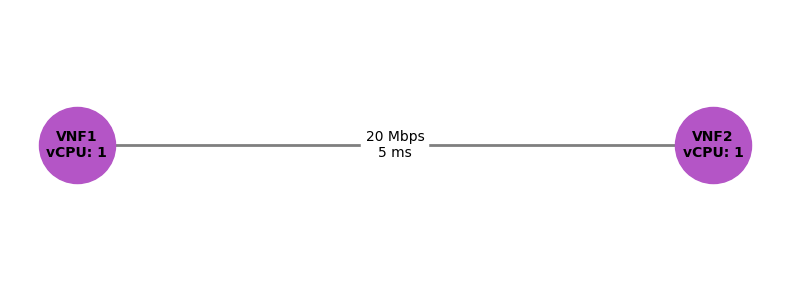

In [23]:
import matplotlib.pyplot as plt
import networkx as nx

# Create slice graph
S = nx.Graph()

# Add VNFs with CPU
S.add_node("VNF1", cpu=1)
S.add_node("VNF2", cpu=1)

# Add virtual link with bandwidth and latency
S.add_edge("VNF1", "VNF2", bw=20, lat=200)

# Fixed horizontal layout
pos = {
    "VNF1": (0, 0),
    "VNF2": (4, 0),
}

plt.figure(figsize=(8, 3))

# Draw nodes (purple like the image)
nx.draw_networkx_nodes(
    S,
    pos,
    node_size=3000,
    node_color="#b455c6",
    #edgecolors="black",
)

# Draw edge (gray)
nx.draw_networkx_edges(
    S,
    pos,
    width=2,
    edge_color="#7f7f7f",
)

# Node labels
node_labels = {
    n: f"{n}\nvCPU: {S.nodes[n]['cpu']}"
    for n in S.nodes()
}
nx.draw_networkx_labels(
    S,
    pos,
    labels=node_labels,
    font_size=10,
    font_weight="bold",
)

# Edge labels
edge_labels = {
    ("VNF1", "VNF2"): "20 Mbps\n5 ms"
}
nx.draw_networkx_edge_labels(
    S,
    pos,
    edge_labels=edge_labels,
    font_size=10,
)


plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# Slice definition
vnfs = ["VNF1", "VNF2"]
vnf_cpu_req = {"VNF1": 1, "VNF2": 1}

# Virtual link requirement (shown under the line)
vl_req = {"bw": 20, "lat": 200}

# Example placement decision (you can change these)
placement = {"VNF1": 5, "VNF2": 4}

# Example routing decision: choose a physical path between placed nodes
# Here: 5 -> 4 -> 1 (short, matches the picture vibe)
route_path = [5, 4]

# Precompute path edges
route_edges = list(zip(route_path[:-1], route_path[1:]))


In [ ]:
def draw_scene(ax, phase: int):
    """
    phase:
      0 = show topology + slice (no mapping)
      1 = show placement (VNFs mapped to nodes)
      2 = show placement + routing (VL mapped to physical path)
    """
    ax.clear()
    ax.set_axis_off()

    # --- Topology (upper part) ---
    nx.draw_networkx_edges(G, pos, ax=ax, width=2, edge_color="gray")
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=900, node_color="#bfe3f2", edgecolors="white", linewidths=2)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=10, font_weight="bold")

    # Node CPU labels (e.g., "10 vCPU")
    for n, (x, y) in pos.items():
        ax.text(x, y - 0.18, f"{node_cpu[n]} vCPU", ha="center", va="center", fontsize=9)

    # Edge labels "bw Mbps\nlat ms"
    edge_labels = {(u, v): f"{d['bw']} Mbps\n{d['lat']} ms" for u, v, d in edges}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, ax=ax, font_size=8, rotate=True)

    # Title for topology
    ax.text(1.1, -1.35, "Example of Network Topology", ha="center", va="center", fontsize=22)

    # --- Slice (lower part) ---
    # Fixed positions for the slice diagram (below)
    slice_y = -2.4
    vnf1_xy = (-0.2, slice_y)
    vnf2_xy = (2.4, slice_y)

    # VNFs as purple circles
    vnf_size = 1300
    ax.scatter([vnf1_xy[0]], [vnf1_xy[1]], s=vnf_size, c="#7b2cbf", edgecolors="white", linewidths=2, zorder=5)
    ax.scatter([vnf2_xy[0]], [vnf2_xy[1]], s=vnf_size, c="#7b2cbf", edgecolors="white", linewidths=2, zorder=5)

    ax.text(vnf1_xy[0], vnf1_xy[1], "VNF1\nvCPU: 1", ha="center", va="center", fontsize=9, color="black", fontweight="bold", zorder=6)
    ax.text(vnf2_xy[0], vnf2_xy[1], "VNF2\nvCPU: 1", ha="center", va="center", fontsize=9, color="black", fontweight="bold", zorder=6)

    # Virtual link line
    ax.plot([vnf1_xy[0] + 0.25, vnf2_xy[0] - 0.25], [slice_y, slice_y], color="gray", linewidth=3, zorder=4)
    ax.text(1.1, slice_y + 0.15, f"{vl_req['bw']} Mbps\n{vl_req['lat']} ms", ha="center", va="center", fontsize=9)

    ax.text(1.1, -3.1, "Example of a Slice with 2 VNFs and 1 VL", ha="center", va="center", fontsize=18)

    # --- Animation overlays ---
    if phase >= 1:
        # Draw mapping arrows: VNF -> node
        # VNF1 -> node placement["VNF1"]
        n1 = placement["VNF1"]
        x1, y1 = pos[n1]
        ax.annotate("", xy=(x1, y1 + 0.15), xytext=(vnf1_xy[0], vnf1_xy[1] + 0.15),
                    arrowprops=dict(arrowstyle="->", lw=3, color="#2f9e44"))
        ax.text((vnf1_xy[0] + x1) / 2, (vnf1_xy[1] + y1) / 2 + 0.2, "place", fontsize=10, color="#2f9e44")

        # VNF2 -> node placement["VNF2"]
        n2 = placement["VNF2"]
        x2, y2 = pos[n2]
        ax.annotate("", xy=(x2, y2 + 0.15), xytext=(vnf2_xy[0], vnf2_xy[1] + 0.15),
                    arrowprops=dict(arrowstyle="->", lw=3, color="#2f9e44"))
        ax.text((vnf2_xy[0] + x2) / 2, (vnf2_xy[1] + y2) / 2 + 0.2, "place", fontsize=10, color="#2f9e44")

    if phase >= 2:
        # Highlight routing path edges
        nx.draw_networkx_edges(G, pos, edgelist=route_edges, ax=ax, width=6, edge_color="#2f9e44")
        # Small


In [ ]:
# Animation timing (in frames)
FPS = 12

# Phase lengths
T0 = 10   # initial pause
T1 = 24   # VNF1 travels to node 5
T2 = 24   # VNF2 travels to node 1
T3 = 30   # VL "traffic" travels along 5-4-1 and BW is consumed

TOTAL_FRAMES = T0 + T1 + T2 + T3

# Initial VNF positions (start "outside" the topology, bottom area)
vnf_start = {
    "VNF1": (-0.2, -1.9),
    "VNF2": (2.4, -1.9),
}

# Target positions = node positions
vnf_target = {
    "VNF1": pos[placement["VNF1"]],
    "VNF2": pos[placement["VNF2"]],
}

def lerp(a, b, t):
    # Linear interpolation
    return (a[0] + (b[0] - a[0]) * t, a[1] + (b[1] - a[1]) * t)

def clamp01(x):
    return max(0.0, min(1.0, x))


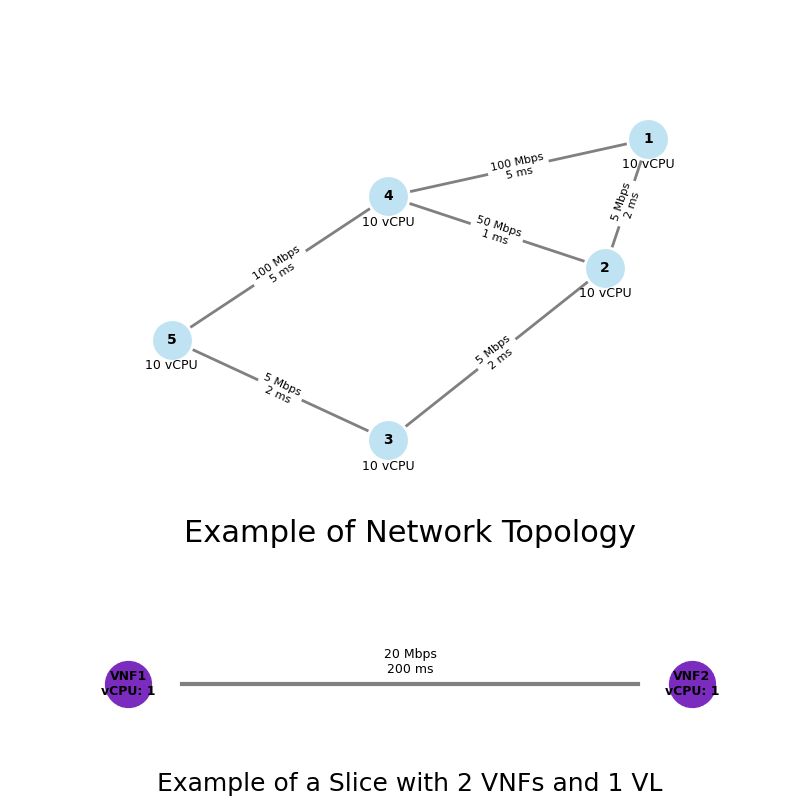

In [ ]:
from IPython.display import Image, display
display(Image(filename="slice_mapping.gif"))


In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter


In [ ]:
# Physical topology graph
G = nx.Graph()

node_cpu_total = {1: 10, 2: 10, 3: 10, 4: 10, 5: 10}
G.add_nodes_from(node_cpu_total.keys())

edges = [
    (5, 4, {"bw": 100, "lat": 5}),
    (4, 1, {"bw": 100, "lat": 5}),
    (1, 2, {"bw": 5,   "lat": 2}),
    (2, 3, {"bw": 5,   "lat": 2}),
    (3, 5, {"bw": 5,   "lat": 2}),
    (4, 2, {"bw": 50,  "lat": 1}),
]
G.add_edges_from([(u, v, d) for u, v, d in edges])

# Fixed positions (match the reference layout)
pos = {
    5: (0.0, 0.0),
    4: (1.0, 1.0),
    1: (2.2, 1.4),
    2: (2.0, 0.5),
    3: (1.0, -0.7),
}


In [ ]:
# Slice (2 VNFs + 1 VL)
vnf_cpu_req = {"VNF1": 1, "VNF2": 1}

# Virtual link requirement (choose values that are feasible on link 5-4)
# Link (5,4) has 100 Mbps and 5 ms in the topology
vl_req = {"bw": 20, "lat": 5}  # you can keep 200ms too; 5ms makes it more "tight" and didactic

# Placement decision: place the slice between nodes 5 and 4
placement = {"VNF1": 5, "VNF2": 4}

# Routing decision: direct physical link 5 -> 4
route_path = [5, 4]
route_edges = list(zip(route_path[:-1], route_path[1:]))

def edge_key(u, v):
    return tuple(sorted((u, v)))

edge_attr = {edge_key(u, v): d for u, v, d in edges}


In [ ]:
# New placement: between 5 and 4
placement = {"VNF1": 5, "VNF2": 4}

# Route must be 5->4 (direct physical link exists)
route_path = [5, 4]
route_edges = list(zip(route_path[:-1], route_path[1:]))

# IMPORTANT: recompute targets after changing placement
vnf_target = {
    "VNF1": pos[placement["VNF1"]],
    "VNF2": pos[placement["VNF2"]],
}

# Slice requirements feasible on link 5-4
vnf_cpu_req = {"VNF1": 1, "VNF2": 1}
vl_req = {"bw": 20, "lat": 5}


In [ ]:
def draw_frame(ax, frame_idx):
    ax.clear()
    ax.set_axis_off()

    # --- Single title (clean) ---
    ax.text(
        1.2, 2.22,
        "Problem statement: joint slice placement and routing",
        ha="center", va="center",
        fontsize=17, fontweight="bold"
    )

    f = frame_idx

    # Start from full resources each frame, then apply "what has happened so far"
    cpu_remaining = dict(node_cpu_total)
    bw_remaining = {k: v["bw"] for k, v in edge_attr.items()}

    # Slice diagram anchor positions (bottom)
    slice_y = -2.00
    slice_vnf_pos = {"VNF1": (-0.2, slice_y), "VNF2": (2.4, slice_y)}

    # Default VNF positions: start at the slice diagram
    vnf_pos = dict(slice_vnf_pos)

    # --- Phase 1: VNF1 travels ---
    placed_vnf1 = False
    if f >= T0:
        t = clamp01((f - T0) / max(1, (T1 - 1)))
        vnf_pos["VNF1"] = lerp(slice_vnf_pos["VNF1"], vnf_target["VNF1"], t)
        if t >= 1.0:
            placed_vnf1 = True
            cpu_remaining[placement["VNF1"]] -= vnf_cpu_req["VNF1"]

    # --- Phase 2: VNF2 travels ---
    placed_vnf2 = False
    if f >= T0 + T1:
        t = clamp01((f - (T0 + T1)) / max(1, (T2 - 1)))
        vnf_pos["VNF2"] = lerp(slice_vnf_pos["VNF2"], vnf_target["VNF2"], t)
        if t >= 1.0:
            placed_vnf2 = True
            cpu_remaining[placement["VNF2"]] -= vnf_cpu_req["VNF2"]

    # --- Phase 3: VL routed (traffic dot) + BW consumption ---
    traffic_progress = 0.0
    if f >= T0 + T1 + T2:
        traffic_progress = clamp01((f - (T0 + T1 + T2)) / max(1, (T3 - 1)))
        for (u, v) in route_edges:
            k = edge_key(u, v)
            bw_remaining[k] = edge_attr[k]["bw"] - int(round(vl_req["bw"] * traffic_progress))

    # --- Draw physical topology ---
    nx.draw_networkx_edges(G, pos, ax=ax, width=2, edge_color="gray")
    nx.draw_networkx_nodes(
        G, pos, ax=ax,
        node_size=900, node_color="#bfe3f2",
        edgecolors="white", linewidths=2
    )
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=10, font_weight="bold")

    # Node CPU remaining labels (with bbox to avoid clutter)
    for n, (x, y) in pos.items():
        ax.text(
            x, y - 0.25,
            f"{cpu_remaining[n]}/{node_cpu_total[n]} vCPU",
            ha="center", va="top",
            fontsize=8,
            bbox=dict(facecolor="white", alpha=0.75, edgecolor="none", pad=1)
        )

    # Edge BW remaining labels (with bbox)
    edge_labels = {}
    for (u, v, d) in edges:
        k = edge_key(u, v)
        edge_labels[(u, v)] = f"{bw_remaining[k]}/{d['bw']} Mbps\n{d['lat']} ms"
    nx.draw_networkx_edge_labels(
        G, pos, edge_labels=edge_labels, ax=ax,
        font_size=8, rotate=True,
        bbox=dict(facecolor="white", alpha=0.75, edgecolor="none", pad=0.8)
    )

    # Highlight routed path only when traffic starts
    if traffic_progress > 0:
        nx.draw_networkx_edges(G, pos, edgelist=route_edges, ax=ax, width=5, edge_color="#2f9e44", zorder=3)

    # --- Slice diagram at bottom (CLEAN) ---
    # Requirement: VL must disappear when VNFs are allocated
    # We'll fade/hide the VL line as soon as placement starts (f >= T0).
    show_slice_vl = f < T0  # only show initially

    # Draw static VNFs placeholders at bottom (optional, but helps comprehension)
    ax.scatter([slice_vnf_pos["VNF1"][0]], [slice_vnf_pos["VNF1"][1]], s=900, c="#7b2cbf",
               edgecolors="white", linewidths=2, zorder=2)
    ax.scatter([slice_vnf_pos["VNF2"][0]], [slice_vnf_pos["VNF2"][1]], s=900, c="#7b2cbf",
               edgecolors="white", linewidths=2, zorder=2)
    ax.text(slice_vnf_pos["VNF1"][0], slice_vnf_pos["VNF1"][1], "VNF1\nCPU:1",
            ha="center", va="center", fontsize=9, fontweight="bold", zorder=3)
    ax.text(slice_vnf_pos["VNF2"][0], slice_vnf_pos["VNF2"][1], "VNF2\nCPU:1",
            ha="center", va="center", fontsize=9, fontweight="bold", zorder=3)

    # Draw VL line only before placement begins
    if show_slice_vl:
        ax.plot(
            [slice_vnf_pos["VNF1"][0] + 0.25, slice_vnf_pos["VNF2"][0] - 0.25],
            [slice_y, slice_y],
            color="gray", linewidth=3, zorder=1
        )
        ax.text(
            1.1, slice_y + 0.18,
            f"{vl_req['bw']} Mbps\n≤ {vl_req['lat']} ms",
            ha="center", va="center", fontsize=9,
            bbox=dict(facecolor="white", alpha=0.75, edgecolor="none", pad=0.6)
        )

    # --- Moving VNFs (purple circles) ---
    ax.scatter([vnf_pos["VNF1"][0]], [vnf_pos["VNF1"][1]], s=900, c="#7b2cbf",
               edgecolors="white", linewidths=2, zorder=6)
    ax.scatter([vnf_pos["VNF2"][0]], [vnf_pos["VNF2"][1]], s=900, c="#7b2cbf",
               edgecolors="white", linewidths=2, zorder=6)
    ax.text(vnf_pos["VNF1"][0], vnf_pos["VNF1"][1], "VNF1\nCPU:1",
            ha="center", va="center", fontsize=9, fontweight="bold", zorder=7)
    ax.text(vnf_pos["VNF2"][0], vnf_pos["VNF2"][1], "VNF2\nCPU:1",
            ha="center", va="center", fontsize=9, fontweight="bold", zorder=7)

    # --- Traffic dot along route (no extra green text) ---
    if traffic_progress > 0:
        pts = [pos[n] for n in route_path]

        seg_lengths = []
        for i in range(len(pts) - 1):
            dx = pts[i+1][0] - pts[i][0]
            dy = pts[i+1][1] - pts[i][1]
            seg_lengths.append(np.hypot(dx, dy))
        total_len = sum(seg_lengths)

        dist = traffic_progress * total_len

        cur = 0.0
        dot_xy = pts[-1]
        for i, L in enumerate(seg_lengths):
            if dist <= cur + L:
                local_t = (dist - cur) / L if L > 0 else 0.0
                dot_xy = lerp(pts[i], pts[i+1], local_t)
                break
            cur += L

        ax.scatter([dot_xy[0]], [dot_xy[1]], s=120, c="#2f9e44", zorder=10)

    # --- View bounds (more breathing room) ---
    ax.set_xlim(-1.0, 3.35)
    ax.set_ylim(-2.7, 2.35)


In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

anim = FuncAnimation(fig, lambda i: draw_frame(ax, i), frames=TOTAL_FRAMES, interval=1000/FPS, repeat=True)

out_path = "slice_mapping.gif"
anim.save(out_path, writer=PillowWriter(fps=FPS))

plt.close(fig)
out_path


'slice_mapping.gif'

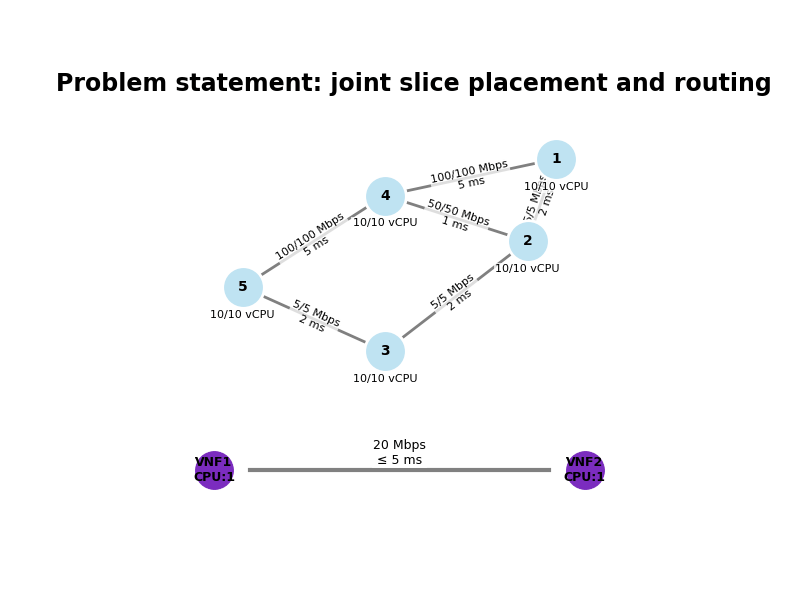

In [ ]:
from IPython.display import Image, display
display(Image(filename="slice_mapping.gif"))


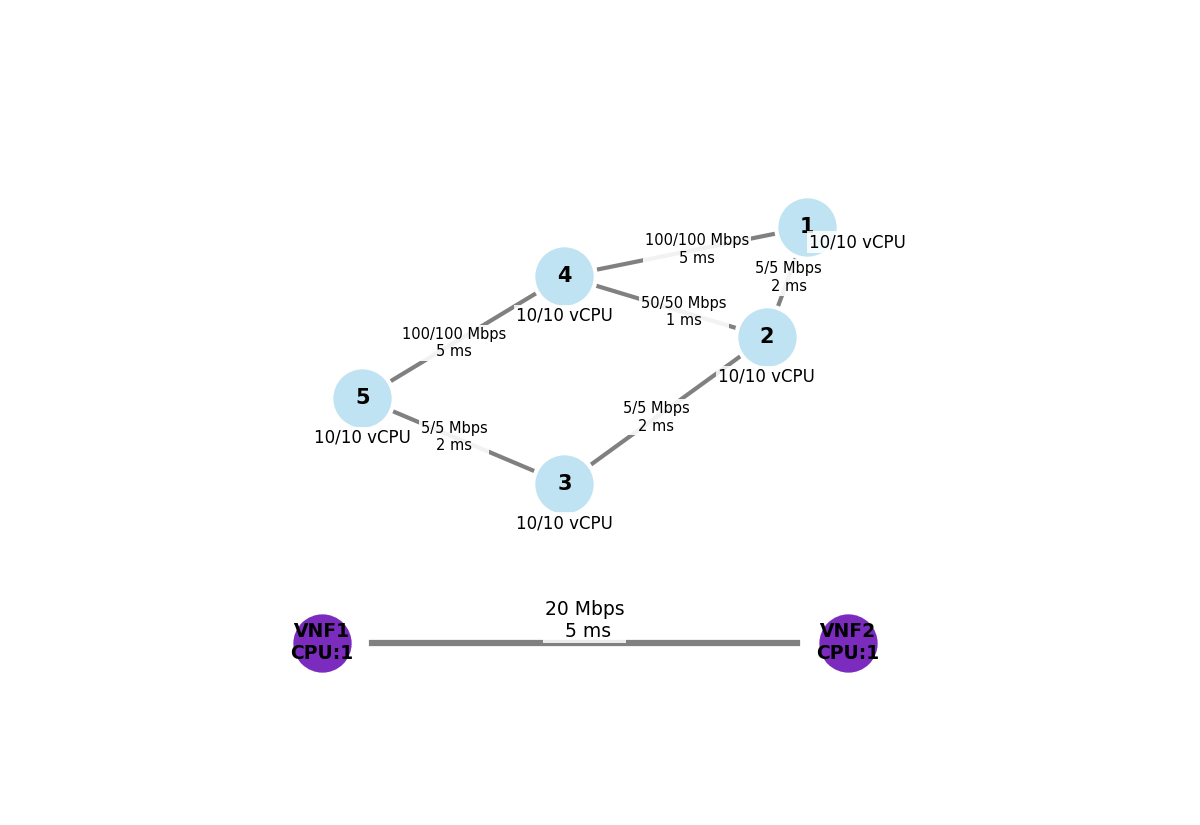

'slice_mapping_clean.gif'

In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image, display

# --- Optional: fine-tuned label positions per edge (avoid overlaps) ---
label_pos_map = {
    tuple(sorted((5, 4))): 0.45,
    tuple(sorted((4, 1))): 0.55,
    tuple(sorted((4, 2))): 0.60,
    tuple(sorted((1, 2))): 0.45,
    tuple(sorted((2, 3))): 0.55,
    tuple(sorted((3, 5))): 0.55,
}

def draw_edge_labels_custom(ax, G, pos, edge_labels):
    # English comment: draw labels one-by-one with custom label_pos
    for (u, v), text in edge_labels.items():
        k = tuple(sorted((u, v)))
        lp = label_pos_map.get(k, 0.5)
        nx.draw_networkx_edge_labels(
            G, pos, ax=ax,
            edge_labels={(u, v): text},
            font_size=7,
            rotate=False,  # English comment: keep horizontal for readability
            label_pos=lp,
            bbox=dict(facecolor="white", alpha=0.90, edgecolor="none", pad=0.9),
        )

def draw_frame(ax, frame_idx):
    ax.clear()
    ax.set_axis_off()

    # Single title
   
    f = frame_idx

    # Start from full resources each frame, then apply what has happened so far
    cpu_remaining = dict(node_cpu_total)
    bw_remaining = {k: v["bw"] for k, v in edge_attr.items()}

    # Slice diagram anchors (bottom)
    slice_y = -2.00
    slice_vnf_pos = {"VNF1": (-0.2, slice_y), "VNF2": (2.4, slice_y)}

    # VNFs start at slice positions
    vnf_pos = dict(slice_vnf_pos)

    # English comment: slice VNFs disappear once they start moving
    show_slice_vnf1 = f < T0
    show_slice_vnf2 = f < (T0 + T1)

    # Phase 1: VNF1 travel
    if f >= T0:
        t = clamp01((f - T0) / max(1, (T1 - 1)))
        vnf_pos["VNF1"] = lerp(slice_vnf_pos["VNF1"], vnf_target["VNF1"], t)
        if t >= 1.0:
            cpu_remaining[placement["VNF1"]] -= vnf_cpu_req["VNF1"]

    # Phase 2: VNF2 travel
    if f >= T0 + T1:
        t = clamp01((f - (T0 + T1)) / max(1, (T2 - 1)))
        vnf_pos["VNF2"] = lerp(slice_vnf_pos["VNF2"], vnf_target["VNF2"], t)
        if t >= 1.0:
            cpu_remaining[placement["VNF2"]] -= vnf_cpu_req["VNF2"]

    # Phase 3: VL routing + BW consumption
    # Phase 3: VL routing + BW consumption (instant step)
    traffic_progress = 0.0
    if f >= T0 + T1 + T2:
        traffic_progress = clamp01((f - (T0 + T1 + T2)) / max(1, (T3 - 1)))

        # English comment: once routing starts, consume full BW immediately (e.g., 100 -> 80)
        for (u, v) in route_edges:
            k = edge_key(u, v)
            bw_remaining[k] = edge_attr[k]["bw"] - vl_req["bw"]


    # --- Draw physical topology ---
    # English comment: draw base edges first (lowest layer)
    nx.draw_networkx_edges(G, pos, ax=ax, width=2, edge_color="gray", alpha=1.0)

    # English comment: highlight routed path BEFORE labels so it cannot cover text
    if traffic_progress > 0:
        nx.draw_networkx_edges(
            G, pos, edgelist=route_edges, ax=ax,
            width=6, edge_color="#2f9e44",
            alpha=0.85
        )

    # Nodes and node ids
    nx.draw_networkx_nodes(
        G, pos, ax=ax,
        node_size=900, node_color="#bfe3f2",
        edgecolors="white", linewidths=2
    )
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=10, font_weight="bold")

    # CPU labels on nodes (with bbox)
    # CPU labels on nodes (with per-node offsets to avoid overlaps)
    node_cpu_offset = {
        1: (0.25, -0.05),  # English comment: move node 1 label slightly right/up
        2: (0.00, -0.25),
        3: (0.00, -0.25),
        4: (0.00, -0.25),
        5: (0.00, -0.25),
    }

    for n, (x, y) in pos.items():
        dx, dy = node_cpu_offset.get(n, (0.0, -0.25))
        ax.text(
            x + dx, y + dy,
            f"{cpu_remaining[n]}/{node_cpu_total[n]} vCPU",
            ha="center", va="top",
            fontsize=8,
            bbox=dict(facecolor="white", alpha=0.85, edgecolor="none", pad=1)
        )


    # Edge labels (BW remaining / total + latency) - drawn LAST
    edge_labels = {}
    for (u, v, d) in edges:
        k = edge_key(u, v)
        edge_labels[(u, v)] = f"{bw_remaining[k]}/{d['bw']} Mbps\n{d['lat']} ms"
    draw_edge_labels_custom(ax, G, pos, edge_labels)

    # --- Slice diagram (bottom) ---
    fade_len = 6  # frames for fade-out
    end_place = T0 + T1 + T2

    if f < end_place:
        show_slice_vl = True
        vl_alpha = 1.0
    elif f < end_place + fade_len:
        show_slice_vl = True
        # English comment: linear fade-out
        vl_alpha = 1.0 - (f - end_place) / fade_len
    else:
        show_slice_vl = False
        vl_alpha = 0.0

    # Draw slice VNFs only while not transported
    if show_slice_vnf1:
        ax.scatter([slice_vnf_pos["VNF1"][0]], [slice_vnf_pos["VNF1"][1]],
                   s=900, c="#7b2cbf", edgecolors="white", linewidths=2, zorder=2)
        ax.text(slice_vnf_pos["VNF1"][0], slice_vnf_pos["VNF1"][1],
                "VNF1\nCPU:1", ha="center", va="center",
                fontsize=9, fontweight="bold", zorder=3)

    if show_slice_vnf2:
        ax.scatter([slice_vnf_pos["VNF2"][0]], [slice_vnf_pos["VNF2"][1]],
                   s=900, c="#7b2cbf", edgecolors="white", linewidths=2, zorder=2)
        ax.text(slice_vnf_pos["VNF2"][0], slice_vnf_pos["VNF2"][1],
                "VNF2\nCPU:1", ha="center", va="center",
                fontsize=9, fontweight="bold", zorder=3)

    # Draw VL line only while visible
    if show_slice_vl:
        ax.plot(
            [slice_vnf_pos["VNF1"][0] + 0.25, slice_vnf_pos["VNF2"][0] - 0.25],
            [slice_y, slice_y],
            color="gray", linewidth=3, zorder=1, alpha=vl_alpha
        )
        ax.text(
            1.1, slice_y + 0.18,
            f"{vl_req['bw']} Mbps\n {vl_req['lat']} ms",
            ha="center", va="center", fontsize=9,
            bbox=dict(facecolor="white", alpha=0.85, edgecolor="none", pad=0.7),
            alpha=vl_alpha
        )

    # --- Moving VNFs (purple circles) ---
    ax.scatter([vnf_pos["VNF1"][0]], [vnf_pos["VNF1"][1]], s=900, c="#7b2cbf",
               edgecolors="white", linewidths=2, zorder=6)
    ax.scatter([vnf_pos["VNF2"][0]], [vnf_pos["VNF2"][1]], s=900, c="#7b2cbf",
               edgecolors="white", linewidths=2, zorder=6)

    ax.text(vnf_pos["VNF1"][0], vnf_pos["VNF1"][1], "VNF1\nCPU:1",
            ha="center", va="center", fontsize=9, fontweight="bold", zorder=7)
    ax.text(vnf_pos["VNF2"][0], vnf_pos["VNF2"][1], "VNF2\nCPU:1",
            ha="center", va="center", fontsize=9, fontweight="bold", zorder=7)

    # --- Traffic dot along route (no extra text) ---
    if traffic_progress > 0:
        pts = [pos[n] for n in route_path]
        seg_lengths = []
        for i in range(len(pts) - 1):
            dx = pts[i+1][0] - pts[i][0]
            dy = pts[i+1][1] - pts[i][1]
            seg_lengths.append(np.hypot(dx, dy))
        total_len = sum(seg_lengths)

        dist = traffic_progress * total_len

        cur = 0.0
        dot_xy = pts[-1]
        for i, L in enumerate(seg_lengths):
            if dist <= cur + L:
                local_t = (dist - cur) / L if L > 0 else 0.0
                dot_xy = lerp(pts[i], pts[i+1], local_t)
                break
            cur += L

        ax.scatter([dot_xy[0]], [dot_xy[1]], s=120, c="#2f9e44", zorder=10)

    # View bounds (breathing room)
    ax.set_xlim(-1.05, 3.55)
    ax.set_ylim(-2.75, 2.45)

# --- Render GIF ---
FPS = 12
TOTAL_FRAMES = (T0 + T1 + T2 + T3)  # assumes these are already defined

fig, ax = plt.subplots(figsize=(8, 5.5), dpi=150)
anim = FuncAnimation(fig, lambda i: draw_frame(ax, i), frames=TOTAL_FRAMES, interval=1000/FPS, repeat=True)

out_path = "slice_mapping_clean.gif"
anim.save(out_path, writer=PillowWriter(fps=FPS))
plt.close(fig)

display(Image(filename=out_path))
out_path
